In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ppo_bc_finetune_schedule.py
# 使用說明：
# - 直接執行此檔會依序做：
#   1) 根據 expert CSV 建立 BC dataset（state, action, action_mask）
#   2) 對 BC dataset 做行為克隆(Behavior Cloning)
#   3) 對 PPO 做 fine-tuning（可以選擇是否用 BC 權重初始化）
# - 會在訓練過程印出：BC 每 10 個 epoch 的 accuracy；PPO 每 10 個 episode 的 episode reward
# - 假設：expert CSV 的 lot_id / group_id 對應到 wip.csv / mach.csv 的 ROW_ID（整數索引）。

import os
import glob, time
import numpy as np
import pandas as pd
from datetime import datetime
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
from torch.utils.data import DataLoader, TensorDataset
from torch.distributions.kl import kl_divergence
import argparse
import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
import copy

from sklearn.preprocessing import StandardScaler
from plotly.colors import qualitative

## Env+PPO

In [ ]:
import gym
import numpy as np
import pandas as pd
from gym import spaces
from datetime import datetime

import gc
import copy
from typing import List, Dict, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical


class SimpleWBEnv(gym.Env):
    """
    單一 agent Wire Bond 排程環境

    功能：
    1. 支援 mach["Arrive"] 作為機群初始可用時間（小時）。
    2. 支援 mach["NEW_RECIPE"] 與 wip["RECIPENAME"] 的改機時間。
    3. 若機群目前 recipe 與子批 recipe 不同，加入 changeover_time。
    4. 使用 wip["DUE_DATE"] 計算 due time。
    5. DUE_DATE 不再減 2 天，直接計算相對 BASE_START_DATE 的小時數。
    6. Observation 包含：
       - 每個機群目前可用時間
       - 每個機群機台數
       - 每個機群負載差異
       - 每個機群目前 recipe
       - 每個子批是否已排程
       - 每個子批 due time
       - 每個子批加工時間
       - 每個子批 recipe
       - 目前排程進度
    """

    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        wip_path: str,
        mach_path: str,
        max_lots: int = 1196,
        max_groups: int = 203,
        reward_mode: str = "linear",
        changeover_time: float = 0.25,
        allowed_recipes=None,
    ):
        super().__init__()

        # =========================================================
        # 固定排程系統起始時間
        # =========================================================
        self.BASE_START_DATE = datetime(2026, 1, 1)

        # 改機時間，單位：小時
        self.changeover_time = float(changeover_time)

        # =========================================================
        # 1. 讀取資料
        # =========================================================
        wip = pd.read_csv(wip_path)
        mach = pd.read_csv(mach_path)

        self.mach = mach.copy()

        # 檢查必要欄位
        required_wip_columns = [
            "RECIPENAME",
            "PROD_TIME",
            "DUE_DATE",
        ]

        required_mach_columns = [
            "EQP_GROUP_ID",
        ]

        missing_wip_columns = [
            col for col in required_wip_columns
            if col not in wip.columns
        ]

        missing_mach_columns = [
            col for col in required_mach_columns
            if col not in mach.columns
        ]

        if missing_wip_columns:
            raise ValueError(
                "wip.csv 缺少必要欄位："
                f"{missing_wip_columns}\n"
                f"目前欄位：{wip.columns.tolist()}"
            )

        if missing_mach_columns:
            raise ValueError(
                "mach.csv 缺少必要欄位："
                f"{missing_mach_columns}\n"
                f"目前欄位：{mach.columns.tolist()}"
            )

        # =========================================================
        # 篩選 WIP
        # =========================================================
        if allowed_recipes is None:
            wip = wip.iloc[:max_lots].reset_index(drop=True)
        else:
            wip = (
                wip[
                    wip["RECIPENAME"].isin(allowed_recipes)
                ]
                .copy()
                .reset_index(drop=True)
            )

        self.wip_df = wip

        # =========================================================
        # 清理子批 recipe 字串
        # =========================================================
        def _clean_recipe(x):
            if pd.isna(x):
                return None

            s = str(x).strip()

            if s == "":
                return None

            return s

        self.lot_recipe = [
            _clean_recipe(x)
            for x in self.wip_df["RECIPENAME"]
        ]

        # =========================================================
        # 建立機群清單
        # =========================================================
        all_groups = (
            self.mach["EQP_GROUP_ID"]
            .dropna()
            .unique()
            .tolist()
        )

        self.group_ids = all_groups[:max_groups]
        self.num_groups = len(self.group_ids)

        if self.num_groups == 0:
            raise ValueError("mach.csv 內沒有有效的 EQP_GROUP_ID。")

        self.num_lots = len(self.wip_df)

        if self.num_lots == 0:
            raise ValueError("wip.csv 內沒有可排程的資料。")

        # 建立機群資料索引，減少後續重複篩選 DataFrame
        self.group_data = {}

        for gid in self.group_ids:
            self.group_data[gid] = self.mach[
                self.mach["EQP_GROUP_ID"] == gid
            ]

        # =========================================================
        # 2. 作業時間，單位：小時
        # =========================================================
        self.process_time = (
            pd.to_numeric(
                self.wip_df["PROD_TIME"],
                errors="coerce",
            )
            .fillna(0.0)
            .to_numpy(dtype=float)
        )

        # 負數加工時間改成 0
        self.process_time = np.maximum(
            self.process_time,
            0.0,
        )

        # =========================================================
        # 3. 計算 due time
        #
        # 修改內容：
        # - 原本輸入欄位為 SOD
        # - 現在改為 DUE_DATE
        # - 不再減 2 天
        # - 直接計算 DUE_DATE 相對 BASE_START_DATE 的小時數
        # =========================================================
        due_datetimes = []

        for row_idx, due_date in enumerate(
            self.wip_df["DUE_DATE"]
        ):
            if pd.isna(due_date):
                due_datetimes.append(None)
                continue

            # 若 pandas 已經辨識成 Timestamp 或 datetime
            if isinstance(due_date, (pd.Timestamp, datetime)):
                due_datetimes.append(
                    pd.Timestamp(due_date).to_pydatetime()
                )
                continue

            s = str(due_date).strip()
            parsed_datetime = None

            supported_formats = (
                "%Y/%m/%d",
                "%Y-%m-%d",
                "%Y/%m/%d %H:%M:%S",
                "%Y-%m-%d %H:%M:%S",
                "%Y/%m/%d %H:%M",
                "%Y-%m-%d %H:%M",
                "%Y/%m/%d %H:%M:%S.%f",
                "%Y-%m-%d %H:%M:%S.%f",
            )

            for fmt in supported_formats:
                try:
                    parsed_datetime = datetime.strptime(
                        s,
                        fmt,
                    )
                    break
                except ValueError:
                    continue

            # 嘗試使用 pandas 自動解析其他日期格式
            if parsed_datetime is None:
                try:
                    parsed_value = pd.to_datetime(
                        s,
                        errors="raise",
                    )

                    parsed_datetime = (
                        parsed_value.to_pydatetime()
                    )

                except Exception as exc:
                    raise ValueError(
                        f'第 {row_idx} 筆資料的 '
                        f'DUE_DATE 無法解析："{due_date}"'
                    ) from exc

            # 不再執行 timedelta(days=2)
            due_datetimes.append(parsed_datetime)

        due_hours = []

        for due_datetime in due_datetimes:
            if due_datetime is None:
                # 缺失日期暫時設定為起始時間，即 due hour = 0
                due_hours.append(0.0)
            else:
                relative_hours = (
                    due_datetime - self.BASE_START_DATE
                ).total_seconds() / 3600.0

                due_hours.append(relative_hours)

        self.due_hours = np.asarray(
            due_hours,
            dtype=float,
        )

        # =========================================================
        # 4. 讀取各機群 m_count
        # =========================================================
        group_mcount = []

        for gid in self.group_ids:
            sub = self.group_data[gid]

            if (
                "m_count" in sub.columns
                and not sub["m_count"].isna().all()
            ):
                mval = pd.to_numeric(
                    sub["m_count"],
                    errors="coerce",
                ).dropna()

                if len(mval) > 0:
                    mval = float(mval.iloc[0])
                else:
                    mval = 1.0
            else:
                mval = 1.0

            if not np.isfinite(mval) or mval <= 0:
                mval = 1.0

            group_mcount.append(mval)

        self.group_mcount = np.asarray(
            group_mcount,
            dtype=float,
        )

        self.max_mcount = float(
            self.group_mcount.max()
            if self.group_mcount.max() > 0
            else 1.0
        )

        # =========================================================
        # 4.5 讀取 Arrive
        # 每個機群的初始可用時間
        # =========================================================
        def _parse_arrive_value(val):
            if pd.isna(val):
                return 0.0

            # 若為純數字，直接視為相對小時數
            if isinstance(
                val,
                (int, float, np.integer, np.floating),
            ):
                try:
                    value = float(val)

                    if np.isfinite(value):
                        return value

                    return 0.0

                except Exception:
                    return 0.0

            # 若已是日期時間型態
            if isinstance(val, (pd.Timestamp, datetime)):
                dt = pd.Timestamp(val).to_pydatetime()

                return (
                    dt - self.BASE_START_DATE
                ).total_seconds() / 3600.0

            s = str(val).strip()

            # 先嘗試解析為數字
            try:
                value = float(s)

                if np.isfinite(value):
                    return value

            except Exception:
                pass

            # 再解析日期時間
            supported_arrive_formats = (
                "%Y/%m/%d %H:%M:%S",
                "%Y/%m/%d %H:%M",
                "%Y/%m/%d",
                "%Y-%m-%d %H:%M:%S",
                "%Y-%m-%d %H:%M",
                "%Y-%m-%d",
                "%Y/%m/%d %H:%M:%S.%f",
                "%Y-%m-%d %H:%M:%S.%f",
            )

            for fmt in supported_arrive_formats:
                try:
                    dt = datetime.strptime(s, fmt)

                    return (
                        dt - self.BASE_START_DATE
                    ).total_seconds() / 3600.0

                except ValueError:
                    continue

            # 最後使用 pandas 自動解析
            try:
                dt = pd.to_datetime(
                    s,
                    errors="raise",
                ).to_pydatetime()

                return (
                    dt - self.BASE_START_DATE
                ).total_seconds() / 3600.0

            except Exception:
                return 0.0

        group_arrive = []

        if (
            "Arrive" in mach.columns
            and not mach["Arrive"].isna().all()
        ):
            for gid in self.group_ids:
                sub = self.group_data[gid]

                if len(sub) == 0:
                    group_arrive.append(0.0)
                    continue

                arrive_val = sub["Arrive"].iloc[0]
                arrive_hour = _parse_arrive_value(arrive_val)

                group_arrive.append(arrive_hour)

        else:
            group_arrive = [0.0] * self.num_groups

        self.group_arrive = np.asarray(
            group_arrive,
            dtype=float,
        )

        # =========================================================
        # 4.75 讀取 NEW_RECIPE
        # 並建立全域 recipe_to_id 映射
        # =========================================================
        def _get_group_new_recipe(gid):
            sub = self.group_data[gid]

            if len(sub) == 0:
                return None

            if "NEW_RECIPE" not in sub.columns:
                return None

            value = sub["NEW_RECIPE"].iloc[0]

            return _clean_recipe(value)

        self.group_new_recipe = [
            _get_group_new_recipe(gid)
            for gid in self.group_ids
        ]

        # 收集 WIP 與機群所有 recipe
        unique_recipes = set()

        for recipe in self.lot_recipe:
            if recipe is not None:
                unique_recipes.add(recipe)

        for recipe in self.group_new_recipe:
            if recipe is not None:
                unique_recipes.add(recipe)

        # None 對應 0
        # 其他 recipe 對應 1 到 N
        recipe_list = sorted(unique_recipes)

        self.recipe_to_id = {
            None: 0,
        }

        for recipe_id, recipe in enumerate(
            recipe_list,
            start=1,
        ):
            self.recipe_to_id[recipe] = recipe_id

        self.max_recipe_id = max(
            self.recipe_to_id.values()
        )

        # 每個子批的 recipe id
        self.lot_recipe_id = np.asarray(
            [
                self.recipe_to_id.get(recipe, 0)
                for recipe in self.lot_recipe
            ],
            dtype=float,
        )

        # 每個機群初始 NEW_RECIPE id
        self.group_new_recipe_id = np.asarray(
            [
                self.recipe_to_id.get(recipe, 0)
                for recipe in self.group_new_recipe
            ],
            dtype=float,
        )

        # =========================================================
        # 5. 正規化最大值
        # =========================================================
        max_abs_due = np.max(
            np.abs(self.due_hours)
        )

        self.max_due = float(
            max_abs_due
            if max_abs_due > 0
            else 1.0
        )

        self.max_proc = float(
            self.process_time.max()
            if self.process_time.max() > 0
            else 1.0
        )

        # =========================================================
        # 6. Observation / Action space
        #
        # 每個 group：
        # 1. group_available normalized
        # 2. m_count
        # 3. load difference normalized
        # 4. current recipe normalized
        #
        # 每個 lot：
        # 1. done
        # 2. due normalized
        # 3. process time normalized
        # 4. recipe normalized
        #
        # 最後：
        # 1. step ratio
        # =========================================================
        obs_dim = (
            4 * self.num_groups
            + 4 * self.num_lots
            + 1
        )

        high_val = max(
            1.0,
            self.max_mcount,
        )

        self.observation_space = spaces.Box(
            low=-1.0,
            high=high_val,
            shape=(obs_dim,),
            dtype=np.float32,
        )

        # action = lot_idx * num_groups + group_idx
        self.action_space = spaces.Discrete(
            self.num_lots * self.num_groups
        )

        # =========================================================
        # 初始化狀態變數
        # =========================================================
        self.group_available = None
        self.done_lot = None
        self.finish_time = None
        self.last_recipe_group_id = None
        self.current_step = 0

        # =========================================================
        # Reward 設定
        # =========================================================
        self.reward_mode = str(reward_mode)

        # tardiness 權重
        self.w1 = 0.9

        # setup 權重
        self.w2 = 0.1

        self.reset()

    # =============================================================
    # reset
    # =============================================================
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        # 機群初始可用時間
        self.group_available = (
            self.group_arrive.copy()
        )

        # 子批是否已排程
        self.done_lot = np.zeros(
            self.num_lots,
            dtype=float,
        )

        # 子批完工時間
        self.finish_time = np.zeros(
            self.num_lots,
            dtype=float,
        )

        self.current_step = 0

        # 機群目前 recipe
        # 初始值來自 mach["NEW_RECIPE"]
        self.last_recipe_group_id = (
            self.group_new_recipe_id
            .copy()
            .astype(int)
            .tolist()
        )

        observation = self._get_obs()

        info = {
            "current_step": 0,
            "scheduled_lots": 0,
            "remaining_lots": self.num_lots,
        }

        return observation, info

    # =============================================================
    # step
    # =============================================================
    def step(self, action):
        action = int(action)

        lot_idx = action // self.num_groups
        group_idx = action % self.num_groups

        # ---------------------------------------------------------
        # 無效 action
        # ---------------------------------------------------------
        if (
            lot_idx < 0
            or lot_idx >= self.num_lots
            or group_idx < 0
            or group_idx >= self.num_groups
        ):
            return (
                self._get_obs(),
                -200.0,
                False,
                False,
                {
                    "invalid_action": True,
                    "action": action,
                },
            )

        # ---------------------------------------------------------
        # 重複排程同一子批
        # ---------------------------------------------------------
        if self.done_lot[lot_idx] == 1.0:
            return (
                self._get_obs(),
                -100.0,
                False,
                False,
                {
                    "duplicate_lot": True,
                    "lot_idx": int(lot_idx),
                    "group_idx": int(group_idx),
                },
            )

        # ---------------------------------------------------------
        # 機群原始可用時間
        # ---------------------------------------------------------
        group_available_before = float(
            self.group_available[group_idx]
        )

        start_time = group_available_before

        # ---------------------------------------------------------
        # 加工時間
        # ---------------------------------------------------------
        base_proc_time = float(
            self.process_time[lot_idx]
        )

        mcount = max(
            float(self.group_mcount[group_idx]),
            1.0,
        )

        effective_proc_time = (
            base_proc_time / mcount
        )

        # ---------------------------------------------------------
        # Recipe 與改機判斷
        # ---------------------------------------------------------
        lot_rid = int(
            self.lot_recipe_id[lot_idx]
        )

        prev_rid = int(
            self.last_recipe_group_id[group_idx]
        )

        changeover_applied = False
        applied_changeover_time = 0.0
        setup = 0.0

        # prev_rid = 0 表示沒有初始 recipe
        if (
            prev_rid != 0
            and lot_rid != prev_rid
        ):
            changeover_applied = True
            applied_changeover_time = (
                self.changeover_time
            )

            start_time += applied_changeover_time

            # setup 以該機群機台數表示
            setup = mcount

        # ---------------------------------------------------------
        # 完工時間
        # ---------------------------------------------------------
        finish_time = (
            start_time
            + effective_proc_time
        )

        # ---------------------------------------------------------
        # 更新環境狀態
        # ---------------------------------------------------------
        self.group_available[group_idx] = (
            finish_time
        )

        self.done_lot[lot_idx] = 1.0

        self.finish_time[lot_idx] = (
            finish_time
        )

        self.last_recipe_group_id[group_idx] = (
            lot_rid
        )

        self.current_step += 1

        # ---------------------------------------------------------
        # Due time 與 tardiness
        # ---------------------------------------------------------
        due_time = float(
            self.due_hours[lot_idx]
        )

        tardiness = max(
            0.0,
            finish_time - due_time,
        )

        # ---------------------------------------------------------
        # Reward
        # ---------------------------------------------------------
        r_tardiness = -tardiness

        r_setup = (
            -0.25 * setup
            if changeover_applied
            else 0.0
        )

        if self.reward_mode == "tardiness":
            reward = r_tardiness

        elif self.reward_mode == "setup":
            reward = r_setup

        elif self.reward_mode == "linear":
            reward = (
                self.w1 * r_tardiness
                + self.w2 * r_setup
            )

        else:
            reward = r_tardiness

        # ---------------------------------------------------------
        # Episode 是否完成
        # ---------------------------------------------------------
        terminated = bool(
            self.current_step >= self.num_lots
        )

        truncated = False

        # ---------------------------------------------------------
        # Info
        # ---------------------------------------------------------
        info = {
            "lot_idx": int(lot_idx),
            "lot_id": int(lot_idx),
            "group_idx": int(group_idx),
            "group_id": self.group_ids[group_idx],
            "recipe_id": int(lot_rid),
            "recipe_name": self.lot_recipe[lot_idx],
            "previous_recipe_id": int(prev_rid),
            "group_available_before": float(
                group_available_before
            ),
            "start_time": float(start_time),
            "finish_time": float(finish_time),
            "completion_time": float(finish_time),
            "due_time": float(due_time),
            "due_hour": float(due_time),
            "tardiness": float(tardiness),
            "m_count": float(mcount),
            "base_proc_time": float(base_proc_time),
            "effective_proc_time": float(
                effective_proc_time
            ),
            "changeover": bool(
                changeover_applied
            ),
            "changeover_time": float(
                applied_changeover_time
            ),
            "setup": float(setup),
            "reward_tardiness": float(
                r_tardiness
            ),
            "reward_setup": float(r_setup),
            "reward": float(reward),
            "current_step": int(
                self.current_step
            ),
            "remaining_lots": int(
                self.num_lots
                - self.current_step
            ),
        }

        return (
            self._get_obs(),
            float(reward),
            terminated,
            truncated,
            info,
        )

    # =============================================================
    # Observation
    # =============================================================
    def _get_obs(self):
        # ---------------------------------------------------------
        # 1. 機群目前可用時間
        # ---------------------------------------------------------
        group_norm = (
            self.group_available
            .copy()
            .astype(np.float32)
        )

        max_group_abs = float(
            np.max(np.abs(group_norm))
        ) if len(group_norm) > 0 else 1.0

        if max_group_abs < 1e-6:
            max_group_abs = 1.0

        group_norm = (
            group_norm / max_group_abs
        )

        # ---------------------------------------------------------
        # 2. 機群機台數
        # 保留原始值
        # ---------------------------------------------------------
        mcount = self.group_mcount.astype(
            np.float32
        )

        # ---------------------------------------------------------
        # 3. 機群負載差異
        # ---------------------------------------------------------
        avg_available = float(
            self.group_available.mean()
        ) if len(self.group_available) > 0 else 0.0

        load_diff = (
            self.group_available
            - avg_available
        )

        load_scale = float(
            np.max(np.abs(load_diff))
        ) if len(load_diff) > 0 else 1.0

        if load_scale < 1e-6:
            load_scale = 1.0

        load_diff_norm = np.clip(
            load_diff / load_scale,
            -1.0,
            1.0,
        ).astype(np.float32)

        # ---------------------------------------------------------
        # 4. 每個機群目前 recipe
        # ---------------------------------------------------------
        if self.max_recipe_id > 0:
            group_recipe_norm = (
                np.asarray(
                    self.last_recipe_group_id,
                    dtype=float,
                )
                / float(self.max_recipe_id)
            ).astype(np.float32)

        else:
            group_recipe_norm = np.zeros(
                self.num_groups,
                dtype=np.float32,
            )

        # ---------------------------------------------------------
        # 5. 每個子批是否完成
        # ---------------------------------------------------------
        done_norm = self.done_lot.astype(
            np.float32
        )

        # ---------------------------------------------------------
        # 6. 每個子批 due time
        # 允許負值，例如 DUE_DATE 早於 BASE_START_DATE
        # ---------------------------------------------------------
        due_norm = np.clip(
            self.due_hours / self.max_due,
            -1.0,
            1.0,
        ).astype(np.float32)

        # ---------------------------------------------------------
        # 7. 每個子批加工時間
        # ---------------------------------------------------------
        proc_norm = (
            self.process_time
            / self.max_proc
        ).astype(np.float32)

        # ---------------------------------------------------------
        # 8. 每個子批 recipe
        # ---------------------------------------------------------
        if self.max_recipe_id > 0:
            lot_recipe_norm = (
                self.lot_recipe_id
                / float(self.max_recipe_id)
            ).astype(np.float32)

        else:
            lot_recipe_norm = np.zeros(
                self.num_lots,
                dtype=np.float32,
            )

        # ---------------------------------------------------------
        # 9. 排程進度
        # ---------------------------------------------------------
        step_ratio = np.asarray(
            [
                self.current_step
                / max(1, self.num_lots)
            ],
            dtype=np.float32,
        )

        # ---------------------------------------------------------
        # 合併 observation
        # ---------------------------------------------------------
        observation = np.concatenate(
            [
                group_norm,
                mcount,
                load_diff_norm,
                group_recipe_norm,
                done_norm,
                due_norm,
                proc_norm,
                lot_recipe_norm,
                step_ratio,
            ]
        )

        return observation.astype(
            np.float32
        )

    # =============================================================
    # Action mask
    # =============================================================
    def get_action_mask(self):
        """
        回傳每個 action 是否可選。

        action：
            lot_idx * num_groups + group_idx

        已排程的 lot 對所有 group 都設為 False。
        """
        available_lots = (
            self.done_lot < 0.5
        )

        action_mask = np.repeat(
            available_lots,
            self.num_groups,
        )

        return action_mask.astype(bool)

    # =============================================================
    # 取得目前排程狀態
    # =============================================================
    def get_schedule_summary(self):
        return {
            "num_lots": int(self.num_lots),
            "num_groups": int(self.num_groups),
            "scheduled_lots": int(
                self.done_lot.sum()
            ),
            "remaining_lots": int(
                self.num_lots
                - self.done_lot.sum()
            ),
            "current_step": int(
                self.current_step
            ),
            "group_available": (
                self.group_available.copy()
            ),
            "finish_time": (
                self.finish_time.copy()
            ),
            "due_hours": (
                self.due_hours.copy()
            ),
        }

    def render(self, mode="human"):
        summary = self.get_schedule_summary()

        print(
            f"Step={summary['current_step']} | "
            f"Scheduled={summary['scheduled_lots']}/"
            f"{summary['num_lots']} | "
            f"Remaining={summary['remaining_lots']}"
        )

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# HEnv

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gym import spaces


class HierarchicalWBEnv(SimpleWBEnv):
    """
    Hierarchical Wire Bond Env

    修改重點：
    1. 直接讀取 CLUSTER_FILE_PATH 的 RECIPENAME、CLUSTER 固定分群。
    2. 上層負責將機群分配給 cluster。
    3. 下層 PPO 在 cluster 內選 lot-machine pair。
    4. get_lower_candidates() 會計算 candidate score。
    5. get_lower_obs() 會把 candidate score 放進 lower observation。
    6. machine_available_time_limit：
       - 若 group_available[g] > machine_available_time_limit，
         該機群視為不可選。
    7. 加速：
       - get_selectable_groups 用 np.where。
       - 新增 get_selectable_group_mask。
       - get_lower_candidates 的 lot/group 篩選改成 numpy + 少量 loop。
    8. 新增 urgent due rule：
       - 若 due_hours <= urgent_due_hours，該子批視為急單。
       - 訓練時採 cluster 內硬性兩階段：先只排全部急單，再排一般單。
       - get_lower_candidates(..., urgent_only=True) 時，一般單完全不會進入候選。
       - 預設 urgent_due_hours = 24.0。
       - urgent_due_priority_bonus 保留給急單內部排序使用。
    """

    def __init__(
        self,
        wip_path: str,
        mach_path: str,
        max_recipes: int = 50,
        n_clusters: int = 5,
        cluster_file_path: str = "/content/drive/MyDrive/test/GMM_K=5.xlsx",
        rf_model_path=None,  # 僅保留舊 notebook 相容性，不會載入或使用
        min_lot_ratio_per_cluster: float = 0.05,
        machine_available_time_limit: float = 96.0,

        # =========================
        # urgent due rule
        # =========================
        urgent_due_hours: float = 24.0,
        urgent_due_priority_bonus: float = 5.0,
        urgent_due_proc_weight: float = 0.10,

        **kwargs
    ):
        # =========================
        # 必須最先定義
        # =========================
        self.max_recipes = int(max_recipes)
        self.n_clusters = int(n_clusters)

        self.cluster_file_path = cluster_file_path
        self.rf_model_path = rf_model_path  # deprecated / ignored
        self.min_lot_ratio_per_cluster = float(min_lot_ratio_per_cluster)

        self.machine_available_time_limit = float(machine_available_time_limit)

        # =========================
        # urgent due rule
        # =========================
        self.urgent_due_hours = float(urgent_due_hours)
        self.urgent_due_priority_bonus = float(urgent_due_priority_bonus)
        self.urgent_due_proc_weight = float(urgent_due_proc_weight)

        self.recipe_cluster_id = -np.ones(
            self.max_recipes,
            dtype=np.int32
        )

        self.recipe_cluster_proba = np.zeros(
            (self.max_recipes, self.n_clusters),
            dtype=np.float32
        )

        self.gmm_model = None
        self.gmm_fitted = False

        self.cluster_mapping_df = None
        self.cluster_name_to_id = {}

        self.cluster_group_assignment = {
            c: [] for c in range(self.n_clusters)
        }

        self.group_assigned_cluster = -np.ones(
            1000,
            dtype=np.int32
        )

        self.cluster_missing_recipes = []
        self.cluster_assignment_df = None

        # lower candidate score cache
        self._last_lower_lot_score_map = {}
        self._last_lower_group_score_map = {}
        self._last_lower_lot_raw_score_map = {}
        self._last_lower_group_raw_score_map = {}
        self._last_lower_urgent_only = False

        # =========================
        # 父類初始化
        # =========================
        super().__init__(wip_path, mach_path, **kwargs)

        # =========================
        # lower-level setting
        # =========================
        self.lower_num_lots = 10
        self.lower_num_groups = 20

        # =========================
        # upper obs/action
        # =========================
        upper_obs_dim = self.max_recipes * 4 + self.max_recipes * 3

        self.upper_observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(upper_obs_dim,),
            dtype=np.float32
        )

        self.upper_action_space = spaces.Discrete(
            self.max_recipes * self.max_recipes
        )

        # =========================
        # lower obs/action
        #
        # Group features:
        #   5 * lower_num_groups
        #
        # Lot features:
        #   5 * lower_num_lots
        #
        # Lot-group pair features:
        #   lower_num_lots * lower_num_groups
        #   value = estimated completion time - due_hours
        #
        # Global feature:
        #   1 * step_ratio
        #
        # Default dimension:
        #   5*10 + 5*20 + 20*10 + 1 = 351
        # =========================
        lower_obs_dim = (
            5 * self.lower_num_groups
            + 5 * self.lower_num_lots
            + self.lower_num_lots * self.lower_num_groups
            + 1
        )

        self.lower_observation_space = spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(lower_obs_dim,),
            dtype=np.float32
        )

        self.lower_action_space = spaces.Discrete(
            self.lower_num_lots * self.lower_num_groups
        )

    # =========================================================
    # Reset
    # =========================================================
    def reset(self, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)

        self.cluster_group_assignment = {
            c: [] for c in range(self.n_clusters)
        }

        self.group_assigned_cluster = -np.ones(
            self.num_groups,
            dtype=np.int32
        )

        self._last_lower_lot_score_map = {}
        self._last_lower_group_score_map = {}
        self._last_lower_lot_raw_score_map = {}
        self._last_lower_group_raw_score_map = {}
        self._last_lower_urgent_only = False

        if not self.gmm_fitted:
            self.fit_recipe_gmm_once()

        return obs, info

    # =========================================================
    # Machine availability filter
    # =========================================================
    def get_selectable_group_mask(self, limit_hours=None):
        """
        回傳 bool mask。
        selectable_mask[g] = True 表示 group g 可選。
        """
        if limit_hours is None:
            limit_hours = getattr(self, "machine_available_time_limit", None)

        if limit_hours is None:
            return np.ones(self.num_groups, dtype=bool)

        group_available = np.asarray(
            self.group_available[:self.num_groups],
            dtype=np.float32
        )

        return group_available <= float(limit_hours)

    def get_selectable_groups(self, limit_hours=None):
        selectable_mask = self.get_selectable_group_mask(
            limit_hours=limit_hours
        )

        return np.where(selectable_mask)[0].astype(int).tolist()

    def get_unavailable_groups(self, limit_hours=None):
        selectable_mask = self.get_selectable_group_mask(
            limit_hours=limit_hours
        )

        return np.where(~selectable_mask)[0].astype(int).tolist()

    def is_group_selectable(self, group_idx, limit_hours=None):
        group_idx = int(group_idx)

        if group_idx < 0 or group_idx >= self.num_groups:
            return False

        if limit_hours is None:
            limit_hours = getattr(self, "machine_available_time_limit", None)

        if limit_hours is None:
            return True

        return float(self.group_available[group_idx]) <= float(limit_hours)

    def print_machine_availability_summary(self, limit_hours=None):
        if limit_hours is None:
            limit_hours = getattr(self, "machine_available_time_limit", None)

        selectable_groups = self.get_selectable_groups(limit_hours=limit_hours)
        unavailable_groups = self.get_unavailable_groups(limit_hours=limit_hours)

        print("========== Machine Availability Summary ==========")
        print(f"machine_available_time_limit = {limit_hours}")
        print(f"num_groups = {self.num_groups}")
        print(f"selectable groups = {len(selectable_groups)}")
        print(f"unavailable groups = {len(unavailable_groups)}")
        print()

        if len(unavailable_groups) > 0:
            print("Unavailable groups:")

            for g in unavailable_groups:
                print(
                    f"  group {g}: "
                    f"available_time = {float(self.group_available[g]):.2f} "
                    f"> {float(limit_hours):.2f}"
                )

    # =========================================================
    # Fixed recipe cluster mapping
    # =========================================================
    def _load_cluster_mapping_once(self):
        """
        一次讀取 cluster_file_path。

        必要欄位：
        - RECIPENAME
        - CLUSTER

        不載入 Random Forest，也不重新計算或平衡 cluster。
        """
        if self.cluster_mapping_df is not None:
            return

        if not os.path.exists(self.cluster_file_path):
            raise FileNotFoundError(
                f"找不到 cluster file: {self.cluster_file_path}"
            )

        ext = os.path.splitext(str(self.cluster_file_path))[1].lower()
        if ext in (".xlsx", ".xls"):
            df = pd.read_excel(
                self.cluster_file_path,
                usecols=lambda c: str(c).strip().upper() in {"RECIPENAME", "CLUSTER"},
            )
        elif ext == ".csv":
            df = pd.read_csv(
                self.cluster_file_path,
                usecols=lambda c: str(c).strip().upper() in {"RECIPENAME", "CLUSTER"},
            )
        else:
            raise ValueError(
                "cluster_file_path 只支援 .xlsx、.xls 或 .csv"
            )

        df.columns = [str(c).strip().upper() for c in df.columns]
        required_cols = {"RECIPENAME", "CLUSTER"}
        missing_cols = sorted(required_cols - set(df.columns))
        if missing_cols:
            raise ValueError(
                f"cluster file 缺少欄位: {missing_cols}；"
                f"目前欄位: {df.columns.tolist()}"
            )

        df = df[["RECIPENAME", "CLUSTER"]].copy()
        df = df.dropna(subset=["RECIPENAME", "CLUSTER"])
        df["RECIPENAME"] = df["RECIPENAME"].astype(str).str.strip()
        df = df[df["RECIPENAME"] != ""]
        df["CLUSTER"] = pd.to_numeric(df["CLUSTER"], errors="coerce")
        df = df.dropna(subset=["CLUSTER"])
        df["CLUSTER"] = df["CLUSTER"].astype(np.int32)

        invalid = df[
            (df["CLUSTER"] < 0)
            | (df["CLUSTER"] >= self.n_clusters)
        ]
        if len(invalid) > 0:
            bad = invalid[["RECIPENAME", "CLUSTER"]].head(20).to_dict("records")
            raise ValueError(
                f"cluster file 含有超出 0~{self.n_clusters - 1} 的 CLUSTER: {bad}"
            )

        duplicated = df[df.duplicated("RECIPENAME", keep=False)]
        if len(duplicated) > 0:
            conflict = (
                duplicated.groupby("RECIPENAME")["CLUSTER"]
                .nunique()
            )
            conflict = conflict[conflict > 1]
            if len(conflict) > 0:
                raise ValueError(
                    "同一 RECIPENAME 對應到多個 CLUSTER: "
                    f"{conflict.index.tolist()[:20]}"
                )

        df = (
            df.drop_duplicates("RECIPENAME", keep="first")
            .sort_values(["CLUSTER", "RECIPENAME"])
            .reset_index(drop=True)
        )

        self.cluster_mapping_df = df
        self.cluster_name_to_id = dict(
            zip(df["RECIPENAME"], df["CLUSTER"].astype(int))
        )

    # =========================================================
    # Recipe id -> RECIPENAME
    # =========================================================
    def _get_recipe_name_from_id(self, rid):
        rid = int(rid)

        # SimpleWBEnv 已建立 recipe_to_id，這裡一次建立反向表後 O(1) 查找。
        if not hasattr(self, "_recipe_id_to_name_cache"):
            self._recipe_id_to_name_cache = {
                int(idx): (None if name is None else str(name))
                for name, idx in getattr(self, "recipe_to_id", {}).items()
            }

        return self._recipe_id_to_name_cache.get(rid, None)

    # =========================================================
    # Active recipes
    # =========================================================
    def _get_active_recipe_ids(self):
        done_arr = np.asarray(self.done_lot[:self.num_lots], dtype=np.float32)
        recipe_arr = np.asarray(self.lot_recipe_id[:self.num_lots], dtype=np.int64)
        active = recipe_arr[done_arr == 0.0]
        active = active[(active > 0) & (active < self.max_recipes)]
        return np.unique(active).astype(int).tolist()

    # =========================================================
    # Fixed clustering main function
    # =========================================================
    def fit_recipe_gmm_once(self):
        """
        舊 method 名稱保留，讓 UpperGMMGreedyAgent 與訓練函數不必修改。
        實際上不會 fit GMM，也不會呼叫 RF predict；只載入固定 CLUSTER。
        """
        if self.gmm_fitted:
            return

        self._load_cluster_mapping_once()

        self.recipe_cluster_id[:] = -1
        self.recipe_cluster_proba[:] = 0.0
        self.cluster_missing_recipes = []

        active_recipe_ids = self._get_active_recipe_ids()
        records = []

        summary = self.get_upper_recipe_summary()
        remaining_count = summary["remaining_count"]
        total_proc = summary["total_proc"]

        for rid in active_recipe_ids:
            rid = int(rid)
            recipe_name = self._get_recipe_name_from_id(rid)

            if recipe_name is None or recipe_name not in self.cluster_name_to_id:
                self.cluster_missing_recipes.append((rid, recipe_name))
                continue

            cluster_id = int(self.cluster_name_to_id[recipe_name])
            self.recipe_cluster_id[rid] = cluster_id
            self.recipe_cluster_proba[rid, cluster_id] = 1.0

            records.append({
                "recipe_id": rid,
                "RECIPENAME": recipe_name,
                "CLUSTER": cluster_id,
                "remaining_lots": float(remaining_count[rid]),
                "remaining_total_proc": float(total_proc[rid]),
            })

        if len(active_recipe_ids) > 0 and len(records) == 0:
            raise ValueError(
                "目前 WIP 的 recipe 都無法對應到 cluster file。\n"
                "請確認 RECIPENAME 字串一致，且檔案包含 RECIPENAME、CLUSTER。"
            )

        self.cluster_assignment_df = pd.DataFrame.from_records(
            records,
            columns=[
                "recipe_id",
                "RECIPENAME",
                "CLUSTER",
                "remaining_lots",
                "remaining_total_proc",
            ],
        )

        self.gmm_model = None
        self.gmm_fitted = True

    # 建議的新名稱；舊程式仍可繼續呼叫 fit_recipe_gmm_once()。
    def load_recipe_clusters_once(self):
        self.fit_recipe_gmm_once()

    # =========================================================
    # Upper observation
    # =========================================================
    def get_upper_obs(self):
        wip_features = np.zeros(
            (self.max_recipes, 4),
            dtype=np.float32
        )

        mach_features = np.zeros(
            (self.max_recipes, 3),
            dtype=np.float32
        )

        for lot_idx in range(self.num_lots):
            if self.done_lot[lot_idx] == 0.0:
                r_id = int(self.lot_recipe_id[lot_idx])

                if 0 < r_id < self.max_recipes:
                    due = float(self.due_hours[lot_idx])
                    proc = float(self.process_time[lot_idx])

                    if wip_features[r_id, 3] == 0:
                        wip_features[r_id, 1] = due
                    else:
                        wip_features[r_id, 1] = min(
                            wip_features[r_id, 1],
                            due
                        )

                    wip_features[r_id, 2] += proc
                    wip_features[r_id, 3] += 1
                    wip_features[r_id, 0] = r_id

        for r_id in range(1, self.max_recipes):
            if wip_features[r_id, 3] > 0:
                wip_features[r_id, 2] /= wip_features[r_id, 3]

        for group_idx in range(self.num_groups):
            r_id = int(self.last_recipe_group_id[group_idx])

            if 0 < r_id < self.max_recipes:
                avail_time = float(self.group_available[group_idx])
                m_cnt = float(self.group_mcount[group_idx])

                mach_features[r_id, 1] += avail_time
                mach_features[r_id, 2] += m_cnt
                mach_features[r_id, 0] = r_id

        return np.concatenate([
            wip_features.flatten(),
            mach_features.flatten()
        ]).astype(np.float32)

    # =========================================================
    # Upper recipe summary
    # =========================================================
    def get_upper_recipe_summary(self):
        R = self.max_recipes

        group_available = np.asarray(
            self.group_available[:self.num_groups],
            dtype=np.float32
        )

        total_proc_sum = (
            float(np.sum(self.process_time[:self.num_lots]))
            if len(self.process_time) > 0
            else 1.0
        )

        total_mcount_sum = (
            float(np.sum(self.group_mcount[:self.num_groups]))
            if len(self.group_mcount) > 0
            else 1.0
        )

        overall_avail = (
            float(np.max(group_available))
            if group_available.size > 0
            else 1.0
        )

        done_arr = np.asarray(
            self.done_lot[:self.num_lots],
            dtype=np.float32
        )

        lot_recipe_arr = np.asarray(
            self.lot_recipe_id[:self.num_lots],
            dtype=np.int64
        )

        due_arr = np.asarray(
            self.due_hours[:self.num_lots],
            dtype=np.float32
        )

        proc_arr = np.asarray(
            self.process_time[:self.num_lots],
            dtype=np.float32
        )

        remaining_mask = done_arr == 0.0

        remaining_recipe_ids_all = lot_recipe_arr[remaining_mask]
        remaining_due_all = due_arr[remaining_mask]
        remaining_proc_all = proc_arr[remaining_mask]

        valid_lot_mask = (
            (remaining_recipe_ids_all > 0)
            & (remaining_recipe_ids_all < R)
        )

        remaining_recipe_ids = remaining_recipe_ids_all[valid_lot_mask]
        remaining_due = remaining_due_all[valid_lot_mask]
        remaining_proc = remaining_proc_all[valid_lot_mask]

        remaining_count = np.zeros(R, dtype=np.float32)
        earliest_due = np.full(R, self.max_due, dtype=np.float32)

        due_std = np.zeros(R, dtype=np.float32)
        total_proc = np.zeros(R, dtype=np.float32)
        avg_proc = np.zeros(R, dtype=np.float32)
        proc_std = np.zeros(R, dtype=np.float32)

        if remaining_recipe_ids.size > 0:
            remaining_count = np.bincount(
                remaining_recipe_ids,
                minlength=R
            ).astype(np.float32)[:R]

            total_proc = np.bincount(
                remaining_recipe_ids,
                weights=remaining_proc,
                minlength=R
            ).astype(np.float32)[:R]

            sum_due = np.bincount(
                remaining_recipe_ids,
                weights=remaining_due,
                minlength=R
            ).astype(np.float32)[:R]

            sum_due2 = np.bincount(
                remaining_recipe_ids,
                weights=remaining_due ** 2,
                minlength=R
            ).astype(np.float32)[:R]

            sum_proc2 = np.bincount(
                remaining_recipe_ids,
                weights=remaining_proc ** 2,
                minlength=R
            ).astype(np.float32)[:R]

            active_rids = np.where(remaining_count > 0)[0]

            for rid in active_rids:
                if rid <= 0 or rid >= R:
                    continue

                cnt = float(remaining_count[rid])

                if cnt <= 0:
                    continue

                mask = remaining_recipe_ids == rid

                earliest_due[rid] = float(np.min(remaining_due[mask]))
                avg_proc[rid] = float(total_proc[rid] / cnt)

                due_mean = float(sum_due[rid] / cnt)
                due_var = max(
                    0.0,
                    float(sum_due2[rid] / cnt - due_mean ** 2)
                )
                due_std[rid] = float(np.sqrt(due_var))

                proc_mean = float(total_proc[rid] / cnt)
                proc_var = max(
                    0.0,
                    float(sum_proc2[rid] / cnt - proc_mean ** 2)
                )
                proc_std[rid] = float(np.sqrt(proc_var))

        machine_count = np.zeros(R, dtype=np.float32)
        machine_cap = np.zeros(R, dtype=np.float32)
        machine_avg_avail = np.zeros(R, dtype=np.float32)
        machine_min_avail = np.full(R, overall_avail, dtype=np.float32)
        machine_std_avail = np.zeros(R, dtype=np.float32)
        machine_util = np.zeros(R, dtype=np.float32)

        last_recipe_arr = np.asarray(
            self.last_recipe_group_id[:self.num_groups],
            dtype=np.int64
        )

        group_mcount_arr = np.asarray(
            self.group_mcount[:self.num_groups],
            dtype=np.float32
        )

        valid_group_mask = (
            (last_recipe_arr > 0)
            & (last_recipe_arr < R)
        )

        if np.any(valid_group_mask):
            last_recipe_valid = last_recipe_arr[valid_group_mask]
            group_mcount_valid = group_mcount_arr[valid_group_mask]

            machine_count = np.bincount(
                last_recipe_valid,
                minlength=R
            ).astype(np.float32)[:R]

            machine_cap = np.bincount(
                last_recipe_valid,
                weights=group_mcount_valid,
                minlength=R
            ).astype(np.float32)[:R]

            active_machine_rids = np.where(machine_count > 0)[0]

            for rid in active_machine_rids:
                if rid <= 0 or rid >= R:
                    continue

                grp_idx = np.where(last_recipe_arr == rid)[0]

                if grp_idx.size > 0:
                    group_avail_r = group_available[grp_idx]

                    machine_avg_avail[rid] = float(np.mean(group_avail_r))
                    machine_min_avail[rid] = float(np.min(group_avail_r))

                    machine_std_avail[rid] = (
                        float(np.std(group_avail_r))
                        if grp_idx.size > 1
                        else 0.0
                    )

                    machine_util[rid] = float(
                        machine_cap[rid]
                        / max(1.0, total_mcount_sum)
                    )

        return {
            "remaining_count": remaining_count,
            "earliest_due": earliest_due,
            "due_std": due_std,
            "total_proc": total_proc,
            "avg_proc": avg_proc,
            "proc_std": proc_std,
            "machine_count": machine_count,
            "machine_cap": machine_cap,
            "machine_avg_avail": machine_avg_avail,
            "machine_min_avail": machine_min_avail,
            "machine_std_avail": machine_std_avail,
            "machine_util": machine_util,
            "overall_avail": overall_avail,
            "total_proc_sum": total_proc_sum,
            "total_mcount_sum": total_mcount_sum,
        }

    # =========================================================
    # Get recipe clusters
    # =========================================================
    def get_recipe_clusters(self, summary=None):
        if not self.gmm_fitted:
            self.fit_recipe_gmm_once()

        if summary is None:
            summary = self.get_upper_recipe_summary()

        remaining_count = summary["remaining_count"]
        total_proc = summary["total_proc"]
        earliest_due = summary["earliest_due"]
        due_std = summary["due_std"]
        avg_proc = summary["avg_proc"]
        proc_std = summary["proc_std"]
        machine_count = summary["machine_count"]
        machine_cap = summary["machine_cap"]
        machine_avg_avail = summary["machine_avg_avail"]
        machine_min_avail = summary["machine_min_avail"]
        machine_std_avail = summary["machine_std_avail"]
        machine_util = summary["machine_util"]

        recipe_to_cluster = np.array(
            self.recipe_cluster_id,
            dtype=np.int32
        )

        cluster_recipes = {
            c: [] for c in range(self.n_clusters)
        }

        active_rids = np.where(remaining_count > 0)[0]

        for rid in active_rids:
            if rid <= 0 or rid >= self.max_recipes:
                continue

            c = int(recipe_to_cluster[rid])

            if 0 <= c < self.n_clusters:
                cluster_recipes[c].append(int(rid))

        for c in range(self.n_clusters):
            cluster_recipes[c].sort(
                key=lambda r: (
                    -remaining_count[r],
                    earliest_due[r]
                )
            )

        cluster_stats = {}

        for c in range(self.n_clusters):
            recs = cluster_recipes[c]

            if len(recs) == 0:
                cluster_stats[c] = {
                    "recipe_count": 0.0,
                    "lot_count": 0.0,
                    "total_proc": 0.0,
                    "avg_proc": 0.0,
                    "earliest_due": float(self.max_due),
                    "due_std": 0.0,
                    "proc_std": 0.0,
                    "machine_count": 0.0,
                    "machine_cap": 0.0,
                    "machine_avg_avail": 0.0,
                    "machine_min_avail": 0.0,
                    "machine_std_avail": 0.0,
                    "machine_util": 0.0,
                }
                continue

            recs_arr = np.asarray(recs, dtype=np.int64)

            cluster_stats[c] = {
                "recipe_count": float(len(recs)),
                "lot_count": float(np.sum(remaining_count[recs_arr])),
                "total_proc": float(np.sum(total_proc[recs_arr])),
                "avg_proc": float(np.mean(avg_proc[recs_arr])),
                "earliest_due": float(np.min(earliest_due[recs_arr])),
                "due_std": float(np.mean(due_std[recs_arr])),
                "proc_std": float(np.mean(proc_std[recs_arr])),
                "machine_count": float(np.sum(machine_count[recs_arr])),
                "machine_cap": float(np.sum(machine_cap[recs_arr])),
                "machine_avg_avail": float(np.mean(machine_avg_avail[recs_arr])),
                "machine_min_avail": float(np.min(machine_min_avail[recs_arr])),
                "machine_std_avail": float(np.mean(machine_std_avail[recs_arr])),
                "machine_util": float(np.mean(machine_util[recs_arr])),
            }

        return {
            "recipe_to_cluster": recipe_to_cluster,
            "cluster_recipes": cluster_recipes,
            "cluster_stats": cluster_stats,
        }

    # =========================================================
    # Allocate groups by cluster
    # =========================================================
    def allocate_groups_by_cluster(self, quota_map, cluster_recipes=None):
        cluster_ids = list(range(self.n_clusters))

        quota_map = {
            int(k): int(v)
            for k, v in quota_map.items()
            if int(v) > 0
        }

        for c in cluster_ids:
            if c not in quota_map:
                quota_map[c] = 0

        selectable_groups = self.get_selectable_groups()
        target_num_groups = len(selectable_groups)

        if target_num_groups == 0:
            self.cluster_group_assignment = {
                c: [] for c in cluster_ids
            }

            self.group_assigned_cluster = -np.ones(
                self.num_groups,
                dtype=np.int32
            )

            print("[Warning] 沒有可選機群：所有 group_available 都超過限制。")
            return self.cluster_group_assignment

        total_quota = int(sum(quota_map.values()))

        if total_quota < target_num_groups:
            if cluster_recipes is None:
                cluster_info = self.get_recipe_clusters()
                cluster_recipes = cluster_info["cluster_recipes"]

            active_clusters = [
                c for c in cluster_ids
                if len(cluster_recipes.get(c, [])) > 0
            ]

            if len(active_clusters) == 0:
                active_clusters = cluster_ids

            for i in range(target_num_groups - total_quota):
                c = active_clusters[i % len(active_clusters)]
                quota_map[c] += 1

        elif total_quota > target_num_groups:
            keys = np.array(cluster_ids, dtype=int)

            vals = np.array(
                [quota_map[k] for k in keys],
                dtype=np.float32
            )

            if vals.sum() <= 0:
                vals = np.ones_like(vals, dtype=np.float32)

            vals = vals / vals.sum() * target_num_groups

            flo = np.floor(vals).astype(int)
            rem = target_num_groups - int(flo.sum())
            frac = vals - flo

            for idx in np.argsort(-frac)[:rem]:
                flo[idx] += 1

            quota_map = {
                int(k): int(v)
                for k, v in zip(keys, flo)
            }

        if cluster_recipes is None:
            cluster_info = self.get_recipe_clusters()
            cluster_recipes = cluster_info["cluster_recipes"]
        else:
            cluster_recipes = {
                int(k): list(v)
                for k, v in cluster_recipes.items()
            }

        self.cluster_group_assignment = {
            c: [] for c in cluster_ids
        }

        self.group_assigned_cluster = -np.ones(
            self.num_groups,
            dtype=np.int32
        )

        selectable_groups_arr = np.asarray(selectable_groups, dtype=np.int64)

        group_order = selectable_groups_arr[
            np.argsort(self.group_available[selectable_groups_arr])
        ].astype(int).tolist()

        for g in group_order:
            g = int(g)

            candidate_clusters = [
                c for c in cluster_ids
                if len(self.cluster_group_assignment[c]) < quota_map.get(c, 0)
            ]

            if len(candidate_clusters) == 0:
                best_fallback_c = min(
                    cluster_ids,
                    key=lambda c: len(self.cluster_group_assignment[c])
                )

                self.cluster_group_assignment[best_fallback_c].append(g)
                self.group_assigned_cluster[g] = int(best_fallback_c)
                continue

            best_c = None
            best_score = None

            last_r = int(self.last_recipe_group_id[g])

            last_cluster = (
                int(self.recipe_cluster_id[last_r])
                if 0 < last_r < self.max_recipes
                else -1
            )

            avail = float(self.group_available[g])

            for c in candidate_clusters:
                same_cluster_bonus = (
                    1.0 if last_cluster == c else 0.0
                )

                changeover_penalty = (
                    0.0
                    if same_cluster_bonus
                    else float(self.changeover_time) * 2.0
                )

                remaining_quota = (
                    quota_map.get(c, 0)
                    - len(self.cluster_group_assignment[c])
                )

                score = (
                    avail
                    + changeover_penalty
                    - 0.25 * same_cluster_bonus
                    - 0.05 * remaining_quota
                )

                if best_score is None or score < best_score:
                    best_score = score
                    best_c = c

            self.cluster_group_assignment[best_c].append(g)
            self.group_assigned_cluster[g] = int(best_c)

        return self.cluster_group_assignment

    def get_allowed_groups_for_cluster(self, cluster_id):
        cluster_id = int(cluster_id)

        return list(
            self.cluster_group_assignment.get(cluster_id, [])
        )

    # =========================================================
    # Score normalization helper
    # =========================================================
    def _normalize_score_map(self, score_map):
        """
        將 raw score 正規化到 [0, 1]。
        分數越小代表候選越好。
        invalid/padding 會在 get_lower_obs 裡設成 1.0。
        """
        if score_map is None or len(score_map) == 0:
            return {}

        keys = list(score_map.keys())
        vals = np.array(
            [float(score_map[k]) for k in keys],
            dtype=np.float32
        )

        v_min = float(np.min(vals))
        v_max = float(np.max(vals))

        if abs(v_max - v_min) < 1e-8:
            return {int(k): 0.0 for k in keys}

        return {
            int(k): float((float(score_map[k]) - v_min) / (v_max - v_min))
            for k in keys
        }

    # =========================================================
    # Urgent-lot helpers
    # =========================================================
    def get_remaining_lots_for_recipe(self, recipe_id, urgent_only=False):
        """回傳指定 recipe 尚未完成的 lot index。"""
        recipe_id = int(recipe_id)
        done_arr = np.asarray(self.done_lot[:self.num_lots], dtype=np.float32)
        recipe_arr = np.asarray(self.lot_recipe_id[:self.num_lots], dtype=np.int64)
        mask = (done_arr == 0.0) & (recipe_arr == recipe_id)

        if urgent_only:
            due_arr = np.asarray(self.due_hours[:self.num_lots], dtype=np.float32)
            mask &= due_arr <= float(getattr(self, "urgent_due_hours", 24.0))

        return np.where(mask)[0].astype(int).tolist()

    def recipe_has_urgent_lots(self, recipe_id):
        """指定 recipe 是否仍有未完成急單。"""
        return len(self.get_remaining_lots_for_recipe(recipe_id, urgent_only=True)) > 0

    def get_urgent_recipes_in_cluster(self, cluster_id, cluster_recipes=None):
        """
        回傳某 cluster 中仍有急單的 recipe ids。
        排序：最早 due、急單數較多、recipe id。
        """
        cluster_id = int(cluster_id)

        if cluster_recipes is None:
            cluster_info = self.get_recipe_clusters()
            cluster_recipes = cluster_info["cluster_recipes"].get(cluster_id, [])

        urgent_info = []

        for rid in cluster_recipes:
            rid = int(rid)
            urgent_lots = self.get_remaining_lots_for_recipe(rid, urgent_only=True)

            if len(urgent_lots) == 0:
                continue

            urgent_lots_arr = np.asarray(urgent_lots, dtype=np.int64)
            earliest_due = float(np.min(self.due_hours[urgent_lots_arr]))
            urgent_info.append((earliest_due, -len(urgent_lots), rid))

        urgent_info.sort()
        return [int(rid) for _, _, rid in urgent_info]

    def cluster_has_urgent_lots(self, cluster_id, cluster_recipes=None):
        """某 cluster 是否仍有任何未完成急單。"""
        return len(self.get_urgent_recipes_in_cluster(cluster_id, cluster_recipes)) > 0

    # =========================================================
    # Lower candidates
    # =========================================================
    def get_lower_candidates(
        self,
        wip_recipe_id,
        mach_recipe_id=None,
        allowed_groups=None,
        return_scores=False,
        urgent_only=False,
    ):
        """
        回傳 lower-level PPO 的候選 lot/group。

        urgent due rule：
        - urgent_only=True：只產生 due_hours <= urgent_due_hours 的急單候選，
          一般單完全不會出現在 action mask 中。
        - urgent_only=False：產生該 recipe 的全部未完成子批。
        - 訓練函數會先檢查整個 cluster；只要 cluster 還有急單，
          所有 lower candidate 都使用 urgent_only=True。
        """
        wip_recipe_id = int(wip_recipe_id)
        self._last_lower_urgent_only = bool(urgent_only)

        # -----------------------------------------------------
        # 1. Lot candidates
        # -----------------------------------------------------
        done_arr = np.asarray(
            self.done_lot[:self.num_lots],
            dtype=np.float32
        )

        lot_recipe_arr = np.asarray(
            self.lot_recipe_id[:self.num_lots],
            dtype=np.int64
        )

        valid_lot_mask = (
            (done_arr == 0.0)
            & (lot_recipe_arr == wip_recipe_id)
        )

        if bool(urgent_only):
            all_due_arr = np.asarray(
                self.due_hours[:self.num_lots],
                dtype=np.float32
            )
            valid_lot_mask &= (
                all_due_arr <= float(getattr(self, "urgent_due_hours", 24.0))
            )

        valid_lots = np.where(valid_lot_mask)[0].astype(int)

        if valid_lots.size == 0:
            self._last_lower_lot_score_map = {}
            self._last_lower_group_score_map = {}
            self._last_lower_lot_raw_score_map = {}
            self._last_lower_group_raw_score_map = {}

            if return_scores:
                return [], [], {}, {}

            return [], []

        max_due = max(1.0, float(self.max_due))
        max_proc = max(1.0, float(self.max_proc))

        due_values = np.asarray(
            self.due_hours[valid_lots],
            dtype=np.float32
        )

        proc_values = np.asarray(
            self.process_time[valid_lots],
            dtype=np.float32
        )

        due_norm = due_values / max_due
        proc_norm = proc_values / max_proc

        urgent_due_hours = float(
            getattr(self, "urgent_due_hours", 24.0)
        )

        urgent_due_priority_bonus = float(
            getattr(self, "urgent_due_priority_bonus", 5.0)
        )

        urgent_due_proc_weight = float(
            getattr(self, "urgent_due_proc_weight", 0.10)
        )

        urgent_mask = due_values <= urgent_due_hours

        normal_lot_score_arr = (
            1.00 * due_norm
            + 0.30 * proc_norm
        )

        urgent_lot_score_arr = (
            1.00 * due_norm
            + urgent_due_proc_weight * proc_norm
            - urgent_due_priority_bonus
        )

        lot_score_arr = np.where(
            urgent_mask,
            urgent_lot_score_arr,
            normal_lot_score_arr
        ).astype(np.float32)

        # -----------------------------------------------------
        # 排序規則：
        # 1. urgent lot 優先
        # 2. lot_score 小的優先
        # 3. due_hours 小的優先
        # 4. process_time 小的優先
        # -----------------------------------------------------
        order = np.lexsort((
            proc_values,
            due_values,
            lot_score_arr,
            ~urgent_mask
        ))

        sorted_lots = valid_lots[order]
        sorted_scores = lot_score_arr[order]

        top_lots = sorted_lots[:self.lower_num_lots].astype(int).tolist()

        lot_raw_score_map = {
            int(l): float(s)
            for l, s in zip(sorted_lots, sorted_scores)
        }

        lot_score_map = self._normalize_score_map(lot_raw_score_map)

        # -----------------------------------------------------
        # 2. Group candidates
        # -----------------------------------------------------
        selectable_mask = self.get_selectable_group_mask()

        if allowed_groups is None:
            candidate_groups = np.where(selectable_mask)[0].astype(int)
        else:
            allowed_arr = np.asarray(
                [
                    int(g)
                    for g in allowed_groups
                    if 0 <= int(g) < self.num_groups
                ],
                dtype=np.int64
            )

            if allowed_arr.size == 0:
                candidate_groups = np.array([], dtype=np.int64)
            else:
                candidate_groups = allowed_arr[
                    selectable_mask[allowed_arr]
                ]

        if candidate_groups.size == 0:
            self._last_lower_lot_score_map = lot_score_map
            self._last_lower_group_score_map = {}
            self._last_lower_lot_raw_score_map = lot_raw_score_map
            self._last_lower_group_raw_score_map = {}

            if return_scores:
                return top_lots, [], lot_score_map, {}

            return top_lots, []

        group_available = np.asarray(
            self.group_available[:self.num_groups],
            dtype=np.float32
        )

        max_avail = max(
            1.0,
            float(group_available.max())
        )

        avg_avail = max(
            1.0,
            float(group_available.mean())
        )

        group_scores = []

        for g in candidate_groups:
            g = int(g)

            avail = float(self.group_available[g])
            last_r = int(self.last_recipe_group_id[g])

            same_recipe = (
                1.0
                if last_r == wip_recipe_id
                else 0.0
            )

            changeover_penalty = (
                0.0
                if same_recipe
                else float(self.changeover_time) * 2.0
            )

            mach_bonus = 0.0

            if mach_recipe_id is not None and last_r == int(mach_recipe_id):
                mach_bonus -= float(self.changeover_time) * 1.5

            avail_norm = avail / max_avail
            load_norm = avail / avg_avail

            same_recipe_bonus = (
                -2.0
                if same_recipe
                else 0.0
            )

            group_score = (
                2.0 * avail_norm
                + 0.5 * load_norm
                + changeover_penalty
                + mach_bonus
                + same_recipe_bonus
            )

            group_scores.append((group_score, g))

        group_scores.sort(key=lambda x: x[0])

        top_groups = [
            int(g)
            for _, g in group_scores[:self.lower_num_groups]
        ]

        group_raw_score_map = {
            int(g): float(score)
            for score, g in group_scores
        }

        group_score_map = self._normalize_score_map(group_raw_score_map)

        # -----------------------------------------------------
        # 3. Cache score maps
        # -----------------------------------------------------
        self._last_lower_lot_score_map = lot_score_map
        self._last_lower_group_score_map = group_score_map
        self._last_lower_lot_raw_score_map = lot_raw_score_map
        self._last_lower_group_raw_score_map = group_raw_score_map

        if return_scores:
            return top_lots, top_groups, lot_score_map, group_score_map

        return top_lots, top_groups

    # =========================================================
    # Lower lot-group estimated completion features
    # =========================================================
    def estimate_lot_group_completion_time(self, lot_idx, group_idx):
        """
        Estimate the completion time when lot_idx is assigned to group_idx.

        completion_time =
            group_available
            + setup_time
            + process_time / group_mcount

        setup_time is zero when the machine group's current recipe matches the
        selected lot recipe; otherwise changeover_time * 2 is added, consistent
        with the candidate scoring logic used in get_lower_candidates().
        """
        lot_idx = int(lot_idx)
        group_idx = int(group_idx)

        if lot_idx < 0 or lot_idx >= self.num_lots:
            return 0.0

        if group_idx < 0 or group_idx >= self.num_groups:
            return 0.0

        available_time = float(self.group_available[group_idx])
        process_time = float(self.process_time[lot_idx])
        machine_count = max(1.0, float(self.group_mcount[group_idx]))

        lot_recipe_id = int(self.lot_recipe_id[lot_idx])
        group_recipe_id = int(self.last_recipe_group_id[group_idx])

        setup_time = (
            0.0
            if lot_recipe_id == group_recipe_id
            else float(self.changeover_time) * 2.0
        )

        effective_process_time = process_time / machine_count

        return float(
            available_time
            + setup_time
            + effective_process_time
        )

    def build_lower_completion_due_matrix(self, pad_lots, pad_groups):
        """
        Build a lot-group pair matrix.

        matrix[i, j] =
            estimated completion time of pad_lots[i] on pad_groups[j]
            - due_hours of pad_lots[i]

        Interpretation:
        - value < 0: expected early completion
        - value = 0: expected on-time completion or padding
        - value > 0: expected tardiness

        Shape:
            (lower_num_lots, lower_num_groups)

        Flattening is row-major / lot-major:
            lot0-group0, lot0-group1, ..., lot1-group0, ...
        """
        matrix = np.zeros(
            (self.lower_num_lots, self.lower_num_groups),
            dtype=np.float32
        )

        for lot_pos, lot_idx in enumerate(pad_lots):
            lot_idx = int(lot_idx)

            if lot_idx == -1:
                continue

            due_hour = float(self.due_hours[lot_idx])

            for group_pos, group_idx in enumerate(pad_groups):
                group_idx = int(group_idx)

                if group_idx == -1:
                    continue

                completion_time = self.estimate_lot_group_completion_time(
                    lot_idx=lot_idx,
                    group_idx=group_idx,
                )

                matrix[lot_pos, group_pos] = float(
                    completion_time - due_hour
                )

        return matrix

    # =========================================================
    # Lower observation
    # =========================================================
    def get_lower_obs(
        self,
        top_lots,
        top_groups,
        lot_score_map=None,
        group_score_map=None,
    ):
        """
        Build the lower-level observation.

        Components:
        1. Five features for each selected group.
        2. Five features for each selected lot.
        3. One pair feature for every selected lot-group combination:
               estimated_completion_time - due_hours
        4. One global step ratio.

        With 20 lots and 10 groups, the pair block contains 200 values and the
        complete default observation dimension is 351.
        """
        if lot_score_map is None:
            lot_score_map = getattr(
                self,
                "_last_lower_lot_score_map",
                {}
            )

        if group_score_map is None:
            group_score_map = getattr(
                self,
                "_last_lower_group_score_map",
                {}
            )

        pad_lots = list(top_lots) + [-1] * (
            self.lower_num_lots - len(top_lots)
        )

        pad_groups = list(top_groups) + [-1] * (
            self.lower_num_groups - len(top_groups)
        )

        pad_lots = pad_lots[:self.lower_num_lots]
        pad_groups = pad_groups[:self.lower_num_groups]

        group_available = np.asarray(
            self.group_available[:self.num_groups],
            dtype=np.float32
        )

        avg_avail = (
            float(group_available.mean())
            if group_available.size > 0
            else 0.0
        )

        max_avail = (
            float(group_available.max())
            if group_available.size > 0
            else 1.0
        )

        denom = max(
            1e-6,
            float(np.max(np.abs(group_available - avg_avail)))
            if group_available.size > 0
            else 1.0
        )

        # -----------------------------------------------------
        # Group features
        # -----------------------------------------------------
        group_norm = np.array([
            float(group_available[g] / max(1.0, max_avail))
            if g != -1
            else 0.0
            for g in pad_groups
        ], dtype=np.float32)

        mcount = np.array([
            float(self.group_mcount[g])
            if g != -1
            else 0.0
            for g in pad_groups
        ], dtype=np.float32)

        load_diff_norm = np.array([
            float(
                np.clip(
                    (group_available[g] - avg_avail) / denom,
                    -1.0,
                    1.0
                )
            )
            if g != -1
            else 0.0
            for g in pad_groups
        ], dtype=np.float32)

        group_recipe_norm = np.array([
            float(
                self.last_recipe_group_id[g]
                / max(1, self.max_recipe_id)
            )
            if g != -1
            else 0.0
            for g in pad_groups
        ], dtype=np.float32)

        group_candidate_score_norm = np.array([
            float(group_score_map.get(int(g), 1.0))
            if g != -1
            else 1.0
            for g in pad_groups
        ], dtype=np.float32)

        # -----------------------------------------------------
        # Lot features
        # -----------------------------------------------------
        done = np.array([
            float(self.done_lot[l])
            if l != -1
            else 1.0
            for l in pad_lots
        ], dtype=np.float32)

        due_norm = np.array([
            float(self.due_hours[l] / max(1.0, float(self.max_due)))
            if l != -1
            else 0.0
            for l in pad_lots
        ], dtype=np.float32)

        proc_norm = np.array([
            float(self.process_time[l] / max(1.0, float(self.max_proc)))
            if l != -1
            else 0.0
            for l in pad_lots
        ], dtype=np.float32)

        lot_recipe_norm = np.array([
            float(
                self.lot_recipe_id[l]
                / max(1, self.max_recipe_id)
            )
            if l != -1
            else 0.0
            for l in pad_lots
        ], dtype=np.float32)

        lot_candidate_score_norm = np.array([
            float(lot_score_map.get(int(l), 1.0))
            if l != -1
            else 1.0
            for l in pad_lots
        ], dtype=np.float32)

        # -----------------------------------------------------
        # Lot-group pair features
        # -----------------------------------------------------
        completion_due_matrix = self.build_lower_completion_due_matrix(
            pad_lots=pad_lots,
            pad_groups=pad_groups,
        )

        completion_due_flat = completion_due_matrix.reshape(-1).astype(
            np.float32
        )

        # -----------------------------------------------------
        # Global feature
        # -----------------------------------------------------
        step_ratio = np.array([
            float(self.current_step / max(1, self.num_lots))
        ], dtype=np.float32)

        obs = np.concatenate([
            group_norm,
            mcount,
            load_diff_norm,
            group_recipe_norm,
            group_candidate_score_norm,

            done,
            due_norm,
            proc_norm,
            lot_recipe_norm,
            lot_candidate_score_norm,

            completion_due_flat,
            step_ratio,
        ])

        expected_dim = (
            5 * self.lower_num_groups
            + 5 * self.lower_num_lots
            + self.lower_num_lots * self.lower_num_groups
            + 1
        )

        if obs.shape[0] != expected_dim:
            raise RuntimeError(
                "Lower observation dimension mismatch: "
                f"actual={obs.shape[0]}, expected={expected_dim}"
            )

        return obs.astype(np.float32), pad_lots, pad_groups

    def get_lower_completion_due_df(self, top_lots, top_groups):
        """
        Return the lot-group completion-minus-due matrix as a DataFrame.
        This helper is intended for debugging and inspection.
        """
        pad_lots = list(top_lots) + [-1] * (
            self.lower_num_lots - len(top_lots)
        )
        pad_groups = list(top_groups) + [-1] * (
            self.lower_num_groups - len(top_groups)
        )

        pad_lots = pad_lots[:self.lower_num_lots]
        pad_groups = pad_groups[:self.lower_num_groups]

        matrix = self.build_lower_completion_due_matrix(
            pad_lots=pad_lots,
            pad_groups=pad_groups,
        )

        row_labels = []
        for pos, lot_idx in enumerate(pad_lots):
            if lot_idx == -1:
                row_labels.append(f"PAD_LOT_{pos}")
            else:
                row_labels.append(
                    f"lot={lot_idx}, due={float(self.due_hours[lot_idx]):.2f}"
                )

        column_labels = []
        for pos, group_idx in enumerate(pad_groups):
            if group_idx == -1:
                column_labels.append(f"PAD_GROUP_{pos}")
            else:
                column_labels.append(
                    "group="
                    f"{group_idx}, avail={float(self.group_available[group_idx]):.2f}"
                )

        return pd.DataFrame(
            matrix,
            index=row_labels,
            columns=column_labels,
        )

    # =========================================================
    # Debug helper
    # =========================================================
    def get_last_lower_candidate_score_df(self):
        lot_rows = []

        for l, raw_score in getattr(self, "_last_lower_lot_raw_score_map", {}).items():
            l = int(l)

            lot_rows.append({
                "lot_idx": l,
                "RECIPENAME": self.lot_recipe[l] if hasattr(self, "lot_recipe") else None,
                "recipe_id": int(self.lot_recipe_id[l]),
                "due_hours": float(self.due_hours[l]),
                "process_time": float(self.process_time[l]),
                "is_urgent_due": bool(
                    float(self.due_hours[l])
                    <= float(getattr(self, "urgent_due_hours", 24.0))
                ),
                "candidate_mode_urgent_only": bool(
                    getattr(self, "_last_lower_urgent_only", False)
                ),
                "raw_score": float(raw_score),
                "score_norm": float(self._last_lower_lot_score_map.get(l, np.nan)),
            })

        group_rows = []

        for g, raw_score in getattr(self, "_last_lower_group_raw_score_map", {}).items():
            g = int(g)

            group_rows.append({
                "group_idx": g,
                "EQP_GROUP_ID": self.group_ids[g] if hasattr(self, "group_ids") else None,
                "available_time": float(self.group_available[g]),
                "is_selectable": bool(self.is_group_selectable(g)),
                "m_count": float(self.group_mcount[g]),
                "last_recipe_id": int(self.last_recipe_group_id[g]),
                "raw_score": float(raw_score),
                "score_norm": float(self._last_lower_group_score_map.get(g, np.nan)),
            })

        lot_score_df = pd.DataFrame(lot_rows)

        if len(lot_score_df) > 0:
            lot_score_df = lot_score_df.sort_values(
                "raw_score"
            ).reset_index(drop=True)

        group_score_df = pd.DataFrame(group_rows)

        if len(group_score_df) > 0:
            group_score_df = group_score_df.sort_values(
                "raw_score"
            ).reset_index(drop=True)

        return lot_score_df, group_score_df

    def print_cluster_balance_summary(
        self,
        plot=True,
        figsize=(12, 8),
        upper_agent=None,
    ):
        """
        顯示固定 Recipe Cluster 的摘要與散點圖。

        summary_df 欄位：
        -----------------
        CLUSTER
            Cluster 編號。

        recipe_count
            Cluster 內的 Recipe 數量。

        lot_count
            Cluster 內尚未完成的總子批數。

        urgent_lot_count
            Cluster 內尚未完成的急單子批數。
            急單定義：
                due_hours <= urgent_due_hours

        urgent_lot_ratio
            急單數占該 Cluster 尚未完成總子批數的比例。

        total_proc
            Cluster 內尚未完成子批的總工時。

        machine_count
            分配給該 Cluster 的機群數。

        proc_ratio
            該 Cluster 總工時占所有 Cluster 總工時的比例。

        machine_ratio
            該 Cluster 機群數占全部已分配機群數的比例。
        """

        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt

        # =========================================================
        # 1. 確認 Cluster 已載入
        # =========================================================
        if not self.gmm_fitted:
            self.fit_recipe_gmm_once()

        if (
            self.cluster_assignment_df is None
            or len(self.cluster_assignment_df) == 0
        ):
            print("沒有固定 CLUSTER assignment 結果。")
            return None

        # =========================================================
        # 2. 取得最新的 Recipe summary
        # =========================================================
        upper_summary = self.get_upper_recipe_summary()

        remaining_count = np.asarray(
            upper_summary["remaining_count"],
            dtype=np.float32,
        )

        remaining_total_proc = np.asarray(
            upper_summary["total_proc"],
            dtype=np.float32,
        )

        df = self.cluster_assignment_df.copy()

        # 使用目前環境最新的剩餘子批數
        df["remaining_lots"] = (
            df["recipe_id"]
            .map(
                lambda rid: (
                    float(remaining_count[int(rid)])
                    if 0 <= int(rid) < len(remaining_count)
                    else 0.0
                )
            )
        )

        # 使用目前環境最新的剩餘總工時
        df["remaining_total_proc"] = (
            df["recipe_id"]
            .map(
                lambda rid: (
                    float(remaining_total_proc[int(rid)])
                    if 0 <= int(rid) < len(remaining_total_proc)
                    else 0.0
                )
            )
        )

        total_lots = float(
            df["remaining_lots"].sum()
        )

        # =========================================================
        # 3. 基本 Cluster summary
        # =========================================================
        summary_df = (
            df.groupby("CLUSTER")
            .agg(
                recipe_count=(
                    "recipe_id",
                    "count",
                ),
                lot_count=(
                    "remaining_lots",
                    "sum",
                ),
                total_proc=(
                    "remaining_total_proc",
                    "sum",
                ),
            )
            .reset_index()
            .sort_values("CLUSTER")
        )

        # 確保沒有 Recipe 的 Cluster 仍會出現在表格中
        all_clusters_df = pd.DataFrame(
            {
                "CLUSTER": np.arange(
                    self.n_clusters,
                    dtype=int,
                )
            }
        )

        summary_df = all_clusters_df.merge(
            summary_df,
            on="CLUSTER",
            how="left",
        )

        summary_df["recipe_count"] = (
            summary_df["recipe_count"]
            .fillna(0)
            .astype(int)
        )

        summary_df["lot_count"] = (
            summary_df["lot_count"]
            .fillna(0.0)
            .astype(float)
        )

        summary_df["total_proc"] = (
            summary_df["total_proc"]
            .fillna(0.0)
            .astype(float)
        )

        # =========================================================
        # 4. 計算每個 Cluster 的急單數
        # =========================================================
        done_arr = np.asarray(
            self.done_lot[:self.num_lots],
            dtype=np.float32,
        )

        lot_recipe_arr = np.asarray(
            self.lot_recipe_id[:self.num_lots],
            dtype=np.int64,
        )

        due_arr = np.asarray(
            self.due_hours[:self.num_lots],
            dtype=np.float32,
        )

        urgent_due_hours = float(
            getattr(
                self,
                "urgent_due_hours",
                24.0,
            )
        )

        urgent_mask = (
            (done_arr == 0.0)
            & (due_arr <= urgent_due_hours)
            & (lot_recipe_arr > 0)
            & (lot_recipe_arr < self.max_recipes)
        )

        urgent_recipe_ids = lot_recipe_arr[
            urgent_mask
        ]

        if urgent_recipe_ids.size > 0:
            urgent_cluster_ids = np.asarray(
                self.recipe_cluster_id[
                    urgent_recipe_ids
                ],
                dtype=np.int64,
            )

            valid_cluster_mask = (
                (urgent_cluster_ids >= 0)
                & (
                    urgent_cluster_ids
                    < self.n_clusters
                )
            )

            urgent_cluster_ids = (
                urgent_cluster_ids[
                    valid_cluster_mask
                ]
            )

            urgent_count_by_cluster = np.bincount(
                urgent_cluster_ids,
                minlength=self.n_clusters,
            ).astype(int)

        else:
            urgent_count_by_cluster = np.zeros(
                self.n_clusters,
                dtype=int,
            )

        urgent_df = pd.DataFrame(
            {
                "CLUSTER": np.arange(
                    self.n_clusters,
                    dtype=int,
                ),
                "urgent_lot_count": (
                    urgent_count_by_cluster
                ),
            }
        )

        summary_df = summary_df.merge(
            urgent_df,
            on="CLUSTER",
            how="left",
        )

        summary_df["urgent_lot_count"] = (
            summary_df["urgent_lot_count"]
            .fillna(0)
            .astype(int)
        )

        # 急單占該 Cluster 總子批數比例
        summary_df["urgent_lot_ratio"] = np.where(
            summary_df["lot_count"] > 0,
            (
                summary_df["urgent_lot_count"]
                / summary_df["lot_count"]
            ),
            0.0,
        )

        # =========================================================
        # 5. 取得每個 Cluster 的機群數
        # =========================================================
        quota_map = None
        meta = None

        if upper_agent is not None:
            (
                quota_map,
                upper_phi,
                upper_value,
                meta,
            ) = upper_agent.select_allocation(
                self,
                greedy=True,
            )

            machine_count_map = {
                int(cluster_id): int(
                    quota_map.get(
                        int(cluster_id),
                        0,
                    )
                )
                for cluster_id in range(
                    self.n_clusters
                )
            }

            machine_count_source = (
                "upper allocation quota"
            )

        else:
            machine_count_map = {
                int(cluster_id): len(
                    self.cluster_group_assignment.get(
                        int(cluster_id),
                        [],
                    )
                )
                for cluster_id in range(
                    self.n_clusters
                )
            }

            machine_count_source = (
                "current cluster assignment"
            )

        summary_df["machine_count"] = (
            summary_df["CLUSTER"]
            .map(
                lambda cluster_id: int(
                    machine_count_map.get(
                        int(cluster_id),
                        0,
                    )
                )
            )
            .astype(int)
        )

        # =========================================================
        # 6. 比例欄位
        # =========================================================
        total_proc_sum = float(
            summary_df["total_proc"].sum()
        )

        total_machine_sum = float(
            summary_df["machine_count"].sum()
        )

        if total_proc_sum > 0:
            summary_df["proc_ratio"] = (
                summary_df["total_proc"]
                / total_proc_sum
            )
        else:
            summary_df["proc_ratio"] = 0.0

        if total_machine_sum > 0:
            summary_df["machine_ratio"] = (
                summary_df["machine_count"]
                / total_machine_sum
            )
        else:
            summary_df["machine_ratio"] = 0.0

        # =========================================================
        # 7. 欄位順序與型別
        # =========================================================
        summary_df = summary_df[
            [
                "CLUSTER",
                "recipe_count",
                "lot_count",
                "urgent_lot_count",
                "urgent_lot_ratio",
                "total_proc",
                "machine_count",
                "proc_ratio",
                "machine_ratio",
            ]
        ].copy()

        summary_df["CLUSTER"] = (
            summary_df["CLUSTER"]
            .astype(int)
        )

        summary_df["recipe_count"] = (
            summary_df["recipe_count"]
            .astype(int)
        )

        summary_df["urgent_lot_count"] = (
            summary_df["urgent_lot_count"]
            .astype(int)
        )

        summary_df["machine_count"] = (
            summary_df["machine_count"]
            .astype(int)
        )

        # 顯示時較容易閱讀
        summary_display_df = (
            summary_df.copy()
        )

        summary_display_df["lot_count"] = (
            summary_display_df["lot_count"]
            .round(0)
            .astype(int)
        )

        summary_display_df[
            "urgent_lot_ratio"
        ] = (
            summary_display_df[
                "urgent_lot_ratio"
            ]
            .round(4)
        )

        summary_display_df["total_proc"] = (
            summary_display_df["total_proc"]
            .round(2)
        )

        summary_display_df["proc_ratio"] = (
            summary_display_df["proc_ratio"]
            .round(4)
        )

        summary_display_df[
            "machine_ratio"
        ] = (
            summary_display_df[
                "machine_ratio"
            ]
            .round(4)
        )

        # =========================================================
        # 8. Print summary
        # =========================================================
        print(
            "========== Fixed Cluster Balance Summary =========="
        )

        print(
            f"n_clusters = {self.n_clusters}"
        )

        print(
            f"total remaining lots = {total_lots:.0f}"
        )

        print(
            "cluster source = fixed CLUSTER column"
        )

        print(
            "machine count source = "
            f"{machine_count_source}"
        )

        print(
            "urgent due definition = "
            f"due_hours <= {urgent_due_hours:.2f}"
        )

        print(
            "total urgent lots = "
            f"{int(summary_df['urgent_lot_count'].sum())}"
        )

        print()

        self.print_machine_availability_summary(
            limit_hours=getattr(
                self,
                "machine_available_time_limit",
                None,
            )
        )

        if quota_map is not None:
            print()

            print(
                "========== Upper Machine Allocation =========="
            )

            if meta is None:
                meta = {}

            print(
                "allocation_rule = "
                f"{meta.get('allocation_rule', 'unknown')}"
            )

            print(
                "machine_available_time_limit = "
                f"{meta.get('machine_available_time_limit', None)}"
            )

            print(
                "selectable machines = "
                f"{meta.get('num_selectable_groups', None)}"
            )

            print(
                "unavailable machines = "
                f"{meta.get('num_unavailable_groups', None)}"
            )

            print(
                "total allocated machines = "
                f"{int(sum(quota_map.values()))}"
            )

            print(
                f"quota_map = {quota_map}"
            )

        print()
        print(
            summary_display_df.to_string(
                index=False
            )
        )

        # =========================================================
        # 9. 無法對應的 Recipe
        # =========================================================
        if len(self.cluster_missing_recipes) > 0:
            print()

            print(
                "[Warning] 以下 Recipe 無法對應到 "
                "cluster file，已略過："
            )

            for rid, name in (
                self.cluster_missing_recipes[:20]
            ):
                print(
                    f"  rid={rid}, "
                    f"RECIPENAME={name}"
                )

            if (
                len(self.cluster_missing_recipes)
                > 20
            ):
                print(
                    "  ... 還有 "
                    f"{len(self.cluster_missing_recipes) - 20} 筆"
                )

        # =========================================================
        # 10. 不畫圖時直接回傳
        # =========================================================
        if not plot:
            return summary_df

        # =========================================================
        # 11. 建立散點圖資料
        # =========================================================
        plot_df = df.copy()

        plot_df["LOG_REMAINING_LOTS"] = (
            np.log1p(
                plot_df[
                    "remaining_lots"
                ].clip(lower=0)
            )
        )

        plot_df[
            "LOG_REMAINING_TOTAL_PROC"
        ] = np.log1p(
            plot_df[
                "remaining_total_proc"
            ].clip(lower=0)
        )

        fig, ax = plt.subplots(
            figsize=figsize
        )

        cmap = plt.get_cmap("tab10")

        # =========================================================
        # 12. 逐 Cluster 畫散點
        # =========================================================
        for cluster_id in range(
            self.n_clusters
        ):
            cluster_plot_df = plot_df[
                plot_df["CLUSTER"].astype(int)
                == int(cluster_id)
            ]

            # 即使 Cluster 沒有 Recipe，
            # 仍建立空 scatter，使圖例保留該 Cluster
            ax.scatter(
                cluster_plot_df[
                    "LOG_REMAINING_LOTS"
                ],
                cluster_plot_df[
                    "LOG_REMAINING_TOTAL_PROC"
                ],
                color=cmap(
                    cluster_id % 10
                ),

                # 左上角 label 只顯示群別
                label=f"Cluster {cluster_id}",

                # 散點大小
                s=100,

                alpha=0.85,
            )

        # =========================================================
        # 13. Recipe 名稱標籤
        # =========================================================
        for _, row in plot_df.iterrows():
            ax.text(
                row[
                    "LOG_REMAINING_LOTS"
                ],
                row[
                    "LOG_REMAINING_TOTAL_PROC"
                ],
                str(
                    row["RECIPENAME"]
                ),
                fontsize=9,
                ha="left",
                va="bottom",
            )

        # =========================================================
        # 14. 座標軸與標題
        # =========================================================
        ax.set_xlabel(
            "log(1 + Remaining Lot Count)",
            fontsize=14,
        )

        ax.set_ylabel(
            "log(1 + Remaining Total Production Time)",
            fontsize=14,
        )

        ax.tick_params(
            axis="both",
            labelsize=12,
        )

        if upper_agent is not None:
            ax.set_title(
                "Fixed Recipe Cluster Assignment ",
                fontsize=17,
                pad=12,
            )
        else:
            ax.set_title(
                "Fixed Recipe Cluster Assignment ",
                fontsize=17,
                pad=12,
            )

        # =========================================================
        # 15. 左上角 Cluster 圖例
        # =========================================================
        ax.legend(
            title="Cluster",
            loc="upper left",
            frameon=True,
            framealpha=0.95,

            # 放大每一群的 label
            fontsize=15,

            # 放大圖例標題
            title_fontsize=16,

            # 放大圖例中的散點
            markerscale=1.5,

            borderpad=0.8,
            labelspacing=0.6,
            handletextpad=0.5,
        )

        ax.grid(
            True,
            linestyle="--",
            alpha=0.3,
        )

        fig.tight_layout()
        plt.show()

        return summary_df

## upper

In [ ]:
import numpy as np


class UpperGMMGreedyAgent:
    """
    上層機群分配 agent

    功能：
    1. 預設：把可選機群平均分配給 active clusters。
    2. 可設定：根據 cluster 指定每群要分配的機群數。
    3. 只分配 group_available[g] <= unavailable_after_hours 的機群。
    """

    def __init__(
        self,
        env,
        n_clusters: int = 5,
        unavailable_after_hours: float = 96.0,
        cluster_machine_quota=None,
        quota_adjust_mode: str = "normalize",
        **kwargs
    ):
        self.env = env
        self.n_clusters = int(n_clusters)
        self.unavailable_after_hours = float(unavailable_after_hours)

        self.cluster_machine_quota = cluster_machine_quota
        self.quota_adjust_mode = str(quota_adjust_mode)

        setattr(
            self.env,
            "machine_available_time_limit",
            self.unavailable_after_hours
        )

    def set_cluster_machine_quota(self, cluster_machine_quota):
        self.cluster_machine_quota = cluster_machine_quota

    def clear_cluster_machine_quota(self):
        self.cluster_machine_quota = None

    def _get_selectable_groups(self, env):
        setattr(
            env,
            "machine_available_time_limit",
            self.unavailable_after_hours
        )

        if hasattr(env, "get_selectable_groups"):
            return env.get_selectable_groups(
                limit_hours=self.unavailable_after_hours
            )

        group_available = np.asarray(
            env.group_available[:env.num_groups],
            dtype=np.float32
        )

        return np.where(
            group_available <= self.unavailable_after_hours
        )[0].astype(int).tolist()

    def _equal_allocation(self, num_groups, active_clusters):
        quota = {c: 0 for c in range(self.n_clusters)}

        active_clusters = [int(c) for c in active_clusters]

        if len(active_clusters) == 0:
            active_clusters = list(range(self.n_clusters))

        num_groups = int(num_groups)

        if num_groups <= 0:
            return quota

        base = num_groups // len(active_clusters)
        rem = num_groups % len(active_clusters)

        for i, c in enumerate(active_clusters):
            quota[c] = base + (1 if i < rem else 0)

        return quota

    def _parse_custom_quota(self):
        quota = {c: 0 for c in range(self.n_clusters)}

        if self.cluster_machine_quota is None:
            return None

        if isinstance(self.cluster_machine_quota, dict):
            for k, v in self.cluster_machine_quota.items():
                c = int(k)

                if c < 0 or c >= self.n_clusters:
                    raise ValueError(
                        f"cluster_machine_quota 裡有非法 cluster id: {c}. "
                        f"合法範圍是 0 ~ {self.n_clusters - 1}"
                    )

                quota[c] = int(v)

        elif isinstance(self.cluster_machine_quota, (list, tuple, np.ndarray)):
            if len(self.cluster_machine_quota) != self.n_clusters:
                raise ValueError(
                    f"cluster_machine_quota 長度必須等於 n_clusters={self.n_clusters}，"
                    f"但目前長度是 {len(self.cluster_machine_quota)}"
                )

            for c, v in enumerate(self.cluster_machine_quota):
                quota[int(c)] = int(v)

        else:
            raise TypeError(
                "cluster_machine_quota 必須是 None、dict、list、tuple 或 np.ndarray"
            )

        for c, v in quota.items():
            if int(v) < 0:
                raise ValueError(
                    f"cluster_machine_quota[{c}] 不可為負數，目前是 {v}"
                )

        return quota

    def _adjust_quota_to_num_groups(
        self,
        quota_map,
        target_num_groups,
        active_clusters
    ):
        quota_map = {
            int(c): int(quota_map.get(c, 0))
            for c in range(self.n_clusters)
        }

        target_num_groups = int(target_num_groups)
        total_quota = int(sum(quota_map.values()))

        active_clusters = [int(c) for c in active_clusters]

        if len(active_clusters) == 0:
            active_clusters = list(range(self.n_clusters))

        if target_num_groups <= 0:
            return {c: 0 for c in range(self.n_clusters)}

        if total_quota == target_num_groups:
            return quota_map

        mode = self.quota_adjust_mode.lower()

        if mode == "strict":
            raise ValueError(
                f"自訂 cluster_machine_quota 總和 = {total_quota}，"
                f"但可選機群數 = {target_num_groups}。"
            )

        if mode == "fill":
            if total_quota < target_num_groups:
                diff = target_num_groups - total_quota

                for i in range(diff):
                    c = active_clusters[i % len(active_clusters)]
                    quota_map[c] += 1

                return quota_map

            mode = "normalize"

        if mode == "normalize":
            values = np.array(
                [quota_map[c] for c in range(self.n_clusters)],
                dtype=np.float32
            )

            if float(values.sum()) <= 0:
                return self._equal_allocation(
                    num_groups=target_num_groups,
                    active_clusters=active_clusters
                )

            scaled = values / float(values.sum()) * float(target_num_groups)

            flo = np.floor(scaled).astype(int)
            remainder = target_num_groups - int(flo.sum())

            frac = scaled - flo

            for idx in np.argsort(-frac)[:remainder]:
                flo[idx] += 1

            return {
                int(c): int(flo[c])
                for c in range(self.n_clusters)
            }

        raise ValueError(
            f"未知 quota_adjust_mode: {self.quota_adjust_mode}. "
            "請使用 'normalize', 'fill', 或 'strict'"
        )

    def select_allocation(self, env, greedy=True):
        setattr(
            env,
            "machine_available_time_limit",
            self.unavailable_after_hours
        )

        if not env.gmm_fitted:
            env.fit_recipe_gmm_once()

        summary = env.get_upper_recipe_summary()
        cluster_info = env.get_recipe_clusters(summary=summary)

        cluster_recipes = cluster_info["cluster_recipes"]
        cluster_stats = cluster_info["cluster_stats"]

        cluster_ids = list(range(self.n_clusters))

        active_clusters = [
            c for c in cluster_ids
            if len(cluster_recipes.get(c, [])) > 0
            and float(cluster_stats[c]["lot_count"]) > 0
        ]

        if len(active_clusters) == 0:
            active_clusters = cluster_ids

        selectable_groups = self._get_selectable_groups(env)

        selectable_mask = np.zeros(env.num_groups, dtype=bool)
        selectable_mask[selectable_groups] = True

        unavailable_groups = np.where(~selectable_mask)[0].astype(int).tolist()

        num_selectable_groups = len(selectable_groups)

        custom_quota = self._parse_custom_quota()

        if custom_quota is None:
            quota_map = self._equal_allocation(
                num_groups=num_selectable_groups,
                active_clusters=active_clusters
            )

            allocation_rule = "equal_selectable_machine_split"
            requested_quota_map = None

        else:
            requested_quota_map = {
                int(c): int(custom_quota.get(c, 0))
                for c in cluster_ids
            }

            quota_map = self._adjust_quota_to_num_groups(
                quota_map=requested_quota_map,
                target_num_groups=num_selectable_groups,
                active_clusters=active_clusters
            )

            allocation_rule = (
                "custom_cluster_machine_quota"
                f"_{self.quota_adjust_mode}"
            )

        meta = {
            "cluster_recipes": cluster_recipes,
            "cluster_stats": cluster_stats,
            "recipe_to_cluster": cluster_info["recipe_to_cluster"],

            "active_clusters": active_clusters,

            "quota_map": quota_map,
            "requested_quota_map": requested_quota_map,
            "allocation_rule": allocation_rule,
            "quota_adjust_mode": self.quota_adjust_mode,

            "machine_available_time_limit": self.unavailable_after_hours,
            "selectable_groups": selectable_groups,
            "unavailable_groups": unavailable_groups,
            "num_selectable_groups": num_selectable_groups,
            "num_unavailable_groups": len(unavailable_groups),
        }

        upper_phi = None
        upper_value = 0.0

        return quota_map, upper_phi, upper_value, meta

    def save_model(self, path):
        pass

    def load_model(self, path):
        pass

# PPO

In [ ]:
# ----- ActorCritic / PPOAgent / RolloutBuffer / calculate_gae -----
import math
import copy
from typing import List, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical


class RolloutBuffer:
    def __init__(self):
        # 儲存已經算好 GAE 的數據
        self.states = []
        self.actions = []
        self.action_masks = []
        self.action_biases = []
        self.log_probs = []
        self.values = []
        self.advantages = []
        self.returns = []

    def add_trajectory(
        self,
        states,
        actions,
        action_masks,
        action_biases,
        log_probs,
        values,
        advantages,
        returns
    ):
        """將處理好的單一 Lot 軌跡加入 Buffer"""
        self.states.extend(states)
        self.actions.extend(actions)
        self.action_masks.extend(action_masks)
        self.action_biases.extend(action_biases)
        self.log_probs.extend(log_probs)
        self.values.extend(values)
        self.advantages.extend(advantages)
        self.returns.extend(returns)

    def get_batch_tensors(self, device):
        states_t = torch.from_numpy(np.array(self.states, dtype=np.float32)).to(device, non_blocking=True)
        actions_t = torch.from_numpy(np.array(self.actions, dtype=np.int64)).to(device, non_blocking=True)
        action_masks_t = torch.from_numpy(np.array(self.action_masks, dtype=bool)).to(device, non_blocking=True)
        action_biases_t = torch.from_numpy(np.array(self.action_biases, dtype=np.float32)).to(device, non_blocking=True)
        log_probs_t = torch.from_numpy(np.array(self.log_probs, dtype=np.float32)).to(device, non_blocking=True)
        advantages_t = torch.from_numpy(np.array(self.advantages, dtype=np.float32)).to(device, non_blocking=True)
        returns_t = torch.from_numpy(np.array(self.returns, dtype=np.float32)).to(device, non_blocking=True)

        # Advantage normalization
        advantages_t = (advantages_t - advantages_t.mean()) / (advantages_t.std() + 1e-8)

        return states_t, actions_t, action_masks_t, action_biases_t, log_probs_t, advantages_t, returns_t

    def clear(self):
        self.states.clear()
        self.actions.clear()
        self.action_masks.clear()
        self.action_biases.clear()
        self.log_probs.clear()
        self.values.clear()
        self.advantages.clear()
        self.returns.clear()

    def __len__(self):
        return len(self.states)


class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        self.actor = nn.Sequential(
            nn.Linear(state_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )
        self.critic = nn.Sequential(
            nn.Linear(state_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, state, action_mask=None, action_bias=None):
        values = self.critic(state).squeeze(-1)
        action_logits = self.actor(state)

        if action_bias is not None:
            action_logits = action_logits + action_bias

        if action_mask is not None:
            action_logits = action_logits.masked_fill(action_mask == 0, -1e8)

        action_probs = F.softmax(action_logits, dim=-1)
        dist = Categorical(action_probs)
        return dist, values

    def evaluate(self, state, action, action_mask=None, action_bias=None):
        values = self.critic(state).squeeze(-1)
        action_logits = self.actor(state)

        if action_bias is not None:
            action_logits = action_logits + action_bias

        if action_mask is not None:
            action_logits = action_logits.masked_fill(action_mask == 0, -1e8)

        action_probs = F.softmax(action_logits, dim=-1)
        dist = Categorical(action_probs)

        log_probs = dist.log_prob(action)
        entropy = dist.entropy().mean()

        return log_probs, values, entropy

    def get_logits(self, state):
        return self.actor(state)


class PPOAgent:
    def __init__(self, state_size, action_size, lr, gamma, gae_lambda, clip_epsilon, k_epochs, v_coeff, ent_coeff, device='cpu'):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_epsilon = clip_epsilon
        self.k_epochs = k_epochs
        self.v_coeff = v_coeff
        self.ent_coeff = ent_coeff
        self.action_size = action_size
        self.device = device

        self.network = ActorCritic(state_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.network.parameters(), lr=lr)
        self.buffer = RolloutBuffer()

    def get_action_and_value(self, state, action_mask=None, action_bias=None, epsilon=0.0):
        """
        支援 Epsilon-Greedy + action_bias
        """
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        mask_tensor = None
        if action_mask is not None:
            mask_tensor = torch.BoolTensor(action_mask).unsqueeze(0).to(self.device)

        bias_tensor = None
        if action_bias is not None:
            bias_tensor = torch.FloatTensor(action_bias).unsqueeze(0).to(self.device)

        with torch.no_grad():
            dist, value = self.network(
                state_tensor,
                action_mask=mask_tensor,
                action_bias=bias_tensor
            )

        if np.random.random() < epsilon:
            if action_mask is not None:
                valid_indices = np.nonzero(action_mask)[0]
                if len(valid_indices) > 0:
                    action_idx = np.random.choice(valid_indices)
                    action = torch.tensor([action_idx], device=self.device)
                else:
                    action = dist.sample()
            else:
                action_idx = np.random.randint(0, self.action_size)
                action = torch.tensor([action_idx], device=self.device)
        else:
            action = dist.sample()

        log_prob = dist.log_prob(action)

        return action.item(), log_prob.item(), value.item()

    def get_value(self, state):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            _, value = self.network(state_tensor)
        return value.item()

    def learn(self):
        """
        更新網路。注意：GAE 已經在 Buffer 中準備好了。
        """
        if len(self.buffer) == 0:
            return

        states, actions, action_masks, action_biases, old_log_probs, advantages, returns = \
            self.buffer.get_batch_tensors(self.device)

        for _ in range(self.k_epochs):
            log_probs, current_values, entropy = self.network.evaluate(
                states,
                actions,
                action_mask=action_masks,
                action_bias=action_biases
            )

            ratios = torch.exp(log_probs - old_log_probs)
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.clip_epsilon, 1 + self.clip_epsilon) * advantages

            actor_loss = -torch.min(surr1, surr2).mean()
            critic_loss = F.mse_loss(current_values.squeeze(), returns)

            total_loss = actor_loss + (self.v_coeff * critic_loss) - (self.ent_coeff * entropy)

            self.optimizer.zero_grad()
            total_loss.backward()
            nn.utils.clip_grad_norm_(self.network.parameters(), 0.5)
            self.optimizer.step()

        self.buffer.clear()
        if self.device == 'cuda':
            torch.cuda.empty_cache()

    def select_action(self, state, action_mask=None, action_bias=None, mode='test'):
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)

        mask_tensor = None
        if action_mask is not None:
            mask_tensor = torch.BoolTensor(action_mask).unsqueeze(0).to(self.device)

        bias_tensor = None
        if action_bias is not None:
            bias_tensor = torch.FloatTensor(action_bias).unsqueeze(0).to(self.device)

        with torch.no_grad():
            dist, _ = self.network(
                state_tensor,
                action_mask=mask_tensor,
                action_bias=bias_tensor
            )

        action = dist.sample().item()
        return action

    def save_model(self, filepath):
        torch.save({
            'network_state_dict': self.network.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
        }, filepath)

    def load_model(self, filepath):
        checkpoint = torch.load(filepath, map_location=self.device)
        self.network.load_state_dict(checkpoint['network_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.network.train()


def calculate_gae(rewards, values, dones, next_value, gamma, gae_lambda):
    advantages = []
    returns = []
    last_advantage = 0
    extended_values = values + [next_value]

    for t in reversed(range(len(rewards))):
        mask = 1.0 - float(dones[t])
        delta = rewards[t] + gamma * extended_values[t + 1] * mask - extended_values[t]
        last_advantage = delta + gamma * gae_lambda * mask * last_advantage
        advantages.insert(0, last_advantage)

    for adv, val in zip(advantages, values):
        returns.append(adv + val)

    return advantages, returns


def evaluate_actor(actor_model, env, n_episodes=10, max_steps=200, device='cpu'):
    """
    deterministic rollout:
    直接用 actor logits 做 argmax
    """
    actor_model.eval()
    rewards = []

    with torch.no_grad():
        for ep in range(n_episodes):
            obs, _ = env.reset()
            obs = obs.astype(np.float32)
            ep_r = 0.0

            for step in range(max_steps):
                state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)

                # 這裡假設 actor_model 是 ActorCritic，直接拿 actor logits
                if hasattr(actor_model, "get_logits"):
                    logits = actor_model.get_logits(state_t)
                else:
                    logits = actor_model(state_t)

                lot_alive = (env.done_lot == 0.0)
                mask = np.repeat(lot_alive, env.num_groups).astype(bool)
                mask_t = torch.BoolTensor(mask).unsqueeze(0).to(device)

                logits = logits.masked_fill(mask_t == 0, -1e8)
                probs = F.softmax(logits, dim=-1)
                action = torch.argmax(probs, dim=1).item()

                obs, r, done, truncated, info = env.step(action)
                obs = obs.astype(np.float32)
                ep_r += float(r)

                if done:
                    break

            rewards.append(ep_r)

    actor_model.train()
    return rewards


import gc

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def build_same_recipe_bias(env, pad_lots, pad_groups, bias_value=1.5):
    """
    給 lower action space 建 bias。
    action = local_lot_idx * lower_num_groups + local_group_idx

    若 lot recipe == group last recipe，則加上 bias_value。
    """
    bias = np.zeros(env.lower_num_lots * env.lower_num_groups, dtype=np.float32)

    for i, l_idx in enumerate(pad_lots):
        if l_idx == -1 or env.done_lot[l_idx] == 1.0:
            continue

        lot_rid = int(env.lot_recipe_id[l_idx])

        for j, g_idx in enumerate(pad_groups):
            if g_idx == -1:
                continue

            group_rid = int(env.last_recipe_group_id[g_idx])

            if lot_rid != 0 and lot_rid == group_rid:
                bias[i * env.lower_num_groups + j] = bias_value

    return bias

# train ft

In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta


def train_hierarchical_agents_multi_lower(
    upper_agent,
    lower_agents,
    env,
    num_episodes=2000,
    device="cpu",
    min_traj_len=8,
    print_every=10,
    machine_available_time_limit=96.0,
    best_schedule_last_n_episodes=100,
    schedule_base_date=datetime(2026, 1, 1),
):
    """
    Hierarchical Selectable Machine Split + Multi-PPO training。

    功能
    ----
    1. 每個 episode 開始前設定 machine_available_time_limit。
    2. 每個 episode 開始時，上層只進行一次機群分配。
    3. 每個 cluster 使用各自的 PPO lower agent。
    4. cluster 內採硬性急單優先。
    5. 只在最後 best_schedule_last_n_episodes 個 episode：
       - 記錄完整排程。
       - 比較最佳 reward。
       - 保存 best_schedule。
       - 保存最佳 lower PPO 模型。

    Parameters
    ----------
    upper_agent:
        上層機群分配 agent。

    lower_agents:
        每個 cluster 對應一個 PPOAgent。

    env:
        HierarchicalWBEnv。

    num_episodes:
        總訓練 episode 數。

    device:
        PPO 計算裝置。

    min_traj_len:
        cluster trajectory 少於此長度時不更新 PPO。

    print_every:
        每隔多少 episode 顯示一次結果。

    machine_available_time_limit:
        機群初始可用時間限制。

    best_schedule_last_n_episodes:
        只從最後多少個 episode 開始選 best_schedule。
        預設為最後 100 個 episode。

    schedule_base_date:
        排程甘特圖使用的基準日期。

    Returns
    -------
    best_reward:
        最後 N 個 episode 中最高的 reward。

    best_schedule:
        最後 N 個 episode 中最高 reward 對應的排程 DataFrame。

    history_rewards:
        每個 episode 的 reward。

    history_tardiness:
        每個 episode 的總 tardiness。

    history_setup:
        每個 episode 的 setup 次數或 setup 指標。
    """

    # ============================================================
    # 0. 基本檢查與初始化
    # ============================================================
    num_episodes = int(num_episodes)

    if num_episodes <= 0:
        raise ValueError("num_episodes 必須大於 0。")

    best_schedule_last_n_episodes = int(
        best_schedule_last_n_episodes
    )

    if best_schedule_last_n_episodes <= 0:
        raise ValueError(
            "best_schedule_last_n_episodes 必須大於 0。"
        )

    # 如果總 episode 少於 100，就從第 1 個 episode 開始記錄
    best_schedule_last_n_episodes = min(
        best_schedule_last_n_episodes,
        num_episodes
    )

    # 0-based index
    # 例如 num_episodes=2000、last_n=100：
    # ep >= 1900，也就是第 1901～2000 episode
    best_tracking_start_ep = (
        num_episodes - best_schedule_last_n_episodes
    )

    best_reward = -np.inf
    best_schedule = pd.DataFrame()
    best_episode = None

    history_rewards = []
    history_tardiness = []
    history_setup = []

    history_selectable_groups = []
    history_unavailable_groups = []
    history_machine_quota = []

    assert len(lower_agents) == env.n_clusters, (
        f"lower_agents 數量 {len(lower_agents)} "
        f"必須等於 env.n_clusters={env.n_clusters}"
    )

    # 確保 env 和 upper_agent 使用相同限制
    env.machine_available_time_limit = float(
        machine_available_time_limit
    )

    if hasattr(upper_agent, "unavailable_after_hours"):
        upper_agent.unavailable_after_hours = float(
            machine_available_time_limit
        )

    # 確保 recipe clustering 已完成
    if not env.gmm_fitted:
        env.fit_recipe_gmm_once()

    print(
        f"總訓練 episodes：{num_episodes}"
    )

    # ============================================================
    # 1. Episode training loop
    # ============================================================
    for ep in range(num_episodes):
        obs, _ = env.reset()
        done = False

        env.machine_available_time_limit = float(
            machine_available_time_limit
        )

        if hasattr(upper_agent, "unavailable_after_hours"):
            upper_agent.unavailable_after_hours = float(
                machine_available_time_limit
            )

        ep_total_reward = 0.0
        ep_real_tardiness = 0.0
        ep_real_setup = 0.0

        # 是否已經進入最後 N 個 episodes
        track_best_schedule = (
            ep >= best_tracking_start_ep
        )

        # 為了減少前期訓練額外負擔，
        # 只有最後 N 個 episodes 才記錄完整排程
        ep_schedule_records = (
            [] if track_best_schedule else None
        )

        # ========================================================
        # 取得可選與不可選機群
        # ========================================================
        selectable_groups = env.get_selectable_groups(
            limit_hours=machine_available_time_limit
        )

        unavailable_groups = env.get_unavailable_groups(
            limit_hours=machine_available_time_limit
        )

        # ========================================================
        # 沒有可選機群
        # ========================================================
        if len(selectable_groups) == 0:
            history_rewards.append(0.0)
            history_tardiness.append(0.0)
            history_setup.append(0.0)

            history_selectable_groups.append(0)
            history_unavailable_groups.append(env.num_groups)

            history_machine_quota.append({
                c: 0
                for c in range(env.n_clusters)
            })

            # 如果已經進入最後 N 個 episodes，
            # 0 reward 仍可成為目前最佳結果
            if track_best_schedule and 0.0 > best_reward:
                best_reward = 0.0
                best_episode = ep + 1
                best_schedule = pd.DataFrame()

            if (ep + 1) % print_every == 0:
                if track_best_schedule:
                    best_text = f"{best_reward:.2f}"
                else:
                    best_text = "尚未開始比較"

                print(
                    "[Hierarchical Multi-PPO] "
                    f"Ep {ep + 1} | "
                    "Skip: no selectable machines | "
                    f"Best(last "
                    f"{best_schedule_last_n_episodes})="
                    f"{best_text} | "
                    f"Limit={machine_available_time_limit:.2f} | "
                    f"Unavailable="
                    f"{len(unavailable_groups)}/{env.num_groups}"
                )

            continue

        # ========================================================
        # 每個 cluster 各自的 PPO trajectory
        # ========================================================
        lower_memory = {
            c: {
                "states": [],
                "actions": [],
                "masks": [],
                "biases": [],
                "logprobs": [],
                "values": [],
                "rewards": [],
                "dones": [],
                "last_obs": None,
            }
            for c in range(env.n_clusters)
        }

        # ========================================================
        # 2. Episode 開始時，上層只分配一次機群
        # ========================================================
        quota_map, _, _, meta = upper_agent.select_allocation(
            env,
            greedy=True
        )

        env.allocate_groups_by_cluster(
            quota_map,
            cluster_recipes=meta["cluster_recipes"]
        )

        # Episode 開始時的固定機群分配
        initial_machine_quota = {
            c: len(env.get_allowed_groups_for_cluster(c))
            for c in range(env.n_clusters)
        }

        initial_cluster_lots = {
            c: float(meta["cluster_stats"][c]["lot_count"])
            for c in range(env.n_clusters)
        }

        initial_cluster_proc = {
            c: float(meta["cluster_stats"][c]["total_proc"])
            for c in range(env.n_clusters)
        }

        initial_cluster_recipes = {
            c: len(meta["cluster_recipes"].get(c, []))
            for c in range(env.n_clusters)
        }

        active_clusters = meta["active_clusters"]

        # 固定 episode 開始時的 cluster 順序
        cluster_order = sorted(
            active_clusters,
            key=lambda c: (
                meta["cluster_stats"][c]["earliest_due"],
                -meta["cluster_stats"][c]["lot_count"],
                -meta["cluster_stats"][c]["total_proc"],
            )
        )

        macro_reward = 0.0

        # ========================================================
        # 3. Episode 內固定機群分配，進行 lower dispatch
        # ========================================================
        while not done:
            any_scheduled = False

            # 每一輪 while 只更新一次 summary 和 cluster 資訊
            summary_now = env.get_upper_recipe_summary()

            cluster_info_now = env.get_recipe_clusters(
                summary=summary_now
            )

            # 每一輪 while 只建立一次 selectable mask
            if hasattr(env, "get_selectable_group_mask"):
                selectable_group_mask = (
                    env.get_selectable_group_mask(
                        limit_hours=machine_available_time_limit
                    )
                )
            else:
                selectable_group_mask = np.array(
                    [
                        env.is_group_selectable(
                            g,
                            limit_hours=machine_available_time_limit
                        )
                        for g in range(env.num_groups)
                    ],
                    dtype=bool
                )

            # ====================================================
            # 逐 cluster 排程
            # ====================================================
            for cluster_id in cluster_order:
                if done:
                    break

                cluster_id = int(cluster_id)
                lower_agent_c = lower_agents[cluster_id]

                allowed_groups_raw = (
                    env.get_allowed_groups_for_cluster(
                        cluster_id
                    )
                )

                # 固定分配給此 cluster，
                # 且目前仍符合 selectable 條件的 groups
                allowed_groups = [
                    int(g)
                    for g in allowed_groups_raw
                    if (
                        0 <= int(g) < env.num_groups
                        and selectable_group_mask[int(g)]
                    )
                ]

                if len(allowed_groups) == 0:
                    continue

                allowed_group_set = set(allowed_groups)

                recipes_in_cluster_all = (
                    cluster_info_now[
                        "cluster_recipes"
                    ].get(
                        cluster_id,
                        []
                    )
                )

                if len(recipes_in_cluster_all) == 0:
                    continue

                # ================================================
                # 硬性急單優先
                # ================================================
                urgent_recipes = (
                    env.get_urgent_recipes_in_cluster(
                        cluster_id=cluster_id,
                        cluster_recipes=recipes_in_cluster_all
                    )
                )

                cluster_urgent_mode = (
                    len(urgent_recipes) > 0
                )

                if cluster_urgent_mode:
                    recipes_in_cluster = list(
                        urgent_recipes
                    )
                else:
                    recipes_in_cluster = sorted(
                        recipes_in_cluster_all,
                        key=lambda r: (
                            summary_now["earliest_due"][r],
                            -summary_now["remaining_count"][r],
                        )
                    )

                # ================================================
                # 逐 recipe 排程
                # ================================================
                for rid in recipes_in_cluster:
                    if done:
                        break

                    rid = int(rid)

                    top_lots, top_groups = (
                        env.get_lower_candidates(
                            wip_recipe_id=rid,
                            mach_recipe_id=None,
                            allowed_groups=allowed_groups,
                            urgent_only=cluster_urgent_mode
                        )
                    )

                    if (
                        len(top_lots) == 0
                        or len(top_groups) == 0
                    ):
                        continue

                    step_count = min(
                        len(top_lots),
                        len(top_groups)
                    )

                    # ============================================
                    # 逐次 lower action
                    # ============================================
                    for _ in range(step_count):
                        lower_obs, pad_lots, pad_groups = (
                            env.get_lower_obs(
                                top_lots,
                                top_groups
                            )
                        )

                        # ========================================
                        # Action mask
                        # ========================================
                        l_mask = np.zeros(
                            env.lower_num_lots
                            * env.lower_num_groups,
                            dtype=bool
                        )

                        # 先計算 group 是否有效
                        valid_group_flags = []

                        for g_idx in pad_groups:
                            if g_idx == -1:
                                valid_group_flags.append(
                                    False
                                )
                                continue

                            g_idx = int(g_idx)

                            valid = (
                                0 <= g_idx < env.num_groups
                                and selectable_group_mask[g_idx]
                                and g_idx in allowed_group_set
                                and int(
                                    env.group_assigned_cluster[
                                        g_idx
                                    ]
                                ) == cluster_id
                            )

                            valid_group_flags.append(valid)

                        # 先計算 lot 是否有效
                        valid_lot_flags = []

                        for l_idx in pad_lots:
                            if l_idx == -1:
                                valid_lot_flags.append(False)
                                continue

                            l_idx = int(l_idx)

                            valid = (
                                env.done_lot[l_idx] == 0.0
                                and int(
                                    env.lot_recipe_id[l_idx]
                                ) == rid
                                and (
                                    not cluster_urgent_mode
                                    or float(
                                        env.due_hours[l_idx]
                                    )
                                    <= float(
                                        getattr(
                                            env,
                                            "urgent_due_hours",
                                            24.0
                                        )
                                    )
                                )
                            )

                            valid_lot_flags.append(valid)

                        # 建立 lot-machine pair mask
                        for i, l_idx in enumerate(pad_lots):
                            if not valid_lot_flags[i]:
                                continue

                            for j, g_idx in enumerate(
                                pad_groups
                            ):
                                if not valid_group_flags[j]:
                                    continue

                                local_action = (
                                    i * env.lower_num_groups
                                    + j
                                )

                                l_mask[local_action] = True

                        if not l_mask.any():
                            break

                        # ========================================
                        # Same-recipe action bias
                        # ========================================
                        l_bias = build_same_recipe_bias(
                            env,
                            pad_lots,
                            pad_groups,
                            bias_value=0
                        )

                        # ========================================
                        # PPO 選擇 lot-machine pair
                        # ========================================
                        (
                            l_action,
                            l_logp,
                            l_value
                        ) = lower_agent_c.get_action_and_value(
                            lower_obs,
                            action_mask=l_mask,
                            action_bias=l_bias
                        )

                        l_action = int(l_action)

                        local_lot_idx = (
                            l_action
                            // env.lower_num_groups
                        )

                        local_group_idx = (
                            l_action
                            % env.lower_num_groups
                        )

                        global_lot_idx = (
                            pad_lots[local_lot_idx]
                        )

                        global_group_idx = (
                            pad_groups[local_group_idx]
                        )

                        if (
                            global_lot_idx == -1
                            or global_group_idx == -1
                        ):
                            break

                        global_lot_idx = int(
                            global_lot_idx
                        )

                        global_group_idx = int(
                            global_group_idx
                        )

                        # ========================================
                        # 最後安全檢查
                        # ========================================
                        if (
                            global_group_idx < 0
                            or global_group_idx
                            >= env.num_groups
                            or not selectable_group_mask[
                                global_group_idx
                            ]
                        ):
                            break

                        if (
                            global_group_idx
                            not in allowed_group_set
                        ):
                            break

                        if int(
                            env.group_assigned_cluster[
                                global_group_idx
                            ]
                        ) != cluster_id:
                            break

                        global_action = (
                            global_lot_idx
                            * env.num_groups
                            + global_group_idx
                        )

                        # ========================================
                        # Environment step
                        # ========================================
                        (
                            _,
                            reward,
                            env_done,
                            _,
                            info
                        ) = env.step(global_action)

                        any_scheduled = True

                        ep_real_tardiness += float(
                            info.get("tardiness", 0.0)
                        )

                        ep_real_setup += float(
                            info.get(
                                "setup",
                                1.0
                                if info.get(
                                    "changeover",
                                    False
                                )
                                else 0.0
                            )
                        )

                        macro_reward += float(reward)

                        # ========================================
                        # 只在最後 N 個 episodes 記錄排程
                        # ========================================
                        if track_best_schedule:
                            finish_h = float(
                                info.get(
                                    "finish_time",
                                    env.group_available[
                                        global_group_idx
                                    ]
                                )
                            )

                            proc_h = float(
                                info.get(
                                    "effective_proc_time",
                                    0.0
                                )
                            )

                            if info.get(
                                "changeover",
                                False
                            ):
                                setup_h = float(
                                    info.get(
                                        "changeover_time",
                                        0.0
                                    )
                                )
                            else:
                                setup_h = 0.0

                            start_h = (
                                finish_h
                                - proc_h
                                - setup_h
                            )

                            lot_idx = int(
                                info.get(
                                    "lot_idx",
                                    global_lot_idx
                                )
                            )

                            group_idx = int(
                                info.get(
                                    "group_idx",
                                    global_group_idx
                                )
                            )

                            # Recipe 顯示名稱
                            if (
                                hasattr(env, "lot_recipe")
                                and lot_idx
                                < len(env.lot_recipe)
                            ):
                                recipe_name = (
                                    env.lot_recipe[lot_idx]
                                )
                            else:
                                recipe_name = str(
                                    info.get(
                                        "lot_recipe_id",
                                        env.lot_recipe_id[
                                            lot_idx
                                        ]
                                    )
                                )

                            # Due hour
                            if "due_time" in info:
                                due_hour = float(
                                    info["due_time"]
                                )
                            elif hasattr(
                                env,
                                "due_hours"
                            ):
                                due_hour = float(
                                    env.due_hours[lot_idx]
                                )
                            else:
                                due_hour = 0.0

                            ep_schedule_records.append({
                                "Episode": int(ep + 1),
                                "LotIdx": lot_idx,
                                "GroupIdx": group_idx,
                                "Group": (
                                    f"G{group_idx + 1}"
                                ),
                                "Cluster": int(cluster_id),
                                "Recipe": str(recipe_name),

                                "Start": (
                                    schedule_base_date
                                    + timedelta(
                                        hours=start_h
                                    )
                                ),

                                "Finish": (
                                    schedule_base_date
                                    + timedelta(
                                        hours=finish_h
                                    )
                                ),

                                "StartHour": float(start_h),
                                "FinishHour": float(finish_h),
                                "ProcHour": float(proc_h),
                                "SetupHour": float(setup_h),

                                "Changeover": bool(
                                    info.get(
                                        "changeover",
                                        False
                                    )
                                ),

                                "Tardiness": float(
                                    info.get(
                                        "tardiness",
                                        0.0
                                    )
                                ),

                                "DueHour": due_hour,
                                "Reward": float(reward),

                                "SelectableLimitHour": float(
                                    machine_available_time_limit
                                ),
                            })

                        # ========================================
                        # 儲存該 cluster PPO trajectory
                        # ========================================
                        mem = lower_memory[cluster_id]

                        mem["states"].append(lower_obs)
                        mem["actions"].append(l_action)
                        mem["masks"].append(l_mask)
                        mem["biases"].append(l_bias)
                        mem["logprobs"].append(l_logp)
                        mem["values"].append(l_value)
                        mem["rewards"].append(
                            float(reward)
                        )
                        mem["dones"].append(
                            bool(env_done)
                        )
                        mem["last_obs"] = lower_obs

                        if env_done:
                            done = True
                            break

                        # ========================================
                        # 更新同 recipe 候選 lot/group
                        # ========================================
                        top_lots, top_groups = (
                            env.get_lower_candidates(
                                wip_recipe_id=rid,
                                mach_recipe_id=None,
                                allowed_groups=allowed_groups,
                                urgent_only=cluster_urgent_mode
                            )
                        )

                        if (
                            len(top_lots) == 0
                            or len(top_groups) == 0
                        ):
                            break

            # 避免 while 無限迴圈
            if not any_scheduled:
                break

        # ========================================================
        # 4. Episode reward
        # ========================================================
        ep_total_reward += float(macro_reward)

        # ========================================================
        # 5. 每個 cluster 各自更新 PPO
        # ========================================================
        for c in range(env.n_clusters):
            mem = lower_memory[c]
            lower_agent_c = lower_agents[c]

            # trajectory 太短不更新
            if len(mem["states"]) < min_traj_len:
                continue

            if done:
                l_next_val = 0.0
            else:
                if mem["last_obs"] is None:
                    l_next_val = 0.0
                else:
                    l_next_val = float(
                        lower_agent_c.get_value(
                            mem["last_obs"]
                        )
                    )

            l_adv, l_ret = calculate_gae(
                mem["rewards"],
                mem["values"],
                mem["dones"],
                l_next_val,
                lower_agent_c.gamma,
                lower_agent_c.gae_lambda
            )

            l_adv = np.nan_to_num(
                l_adv,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            l_ret = np.nan_to_num(
                l_ret,
                nan=0.0,
                posinf=0.0,
                neginf=0.0
            )

            lower_agent_c.buffer.add_trajectory(
                mem["states"],
                mem["actions"],
                mem["masks"],
                mem["biases"],
                mem["logprobs"],
                mem["values"],
                l_adv,
                l_ret
            )

            lower_agent_c.learn()

        # ========================================================
        # 6. Logging
        # ========================================================
        history_rewards.append(
            float(ep_total_reward)
        )

        history_tardiness.append(
            float(ep_real_tardiness)
        )

        history_setup.append(
            float(ep_real_setup)
        )

        history_selectable_groups.append(
            len(selectable_groups)
        )

        history_unavailable_groups.append(
            len(unavailable_groups)
        )

        history_machine_quota.append(
            initial_machine_quota.copy()
        )

        # ========================================================
        # 7. 只在最後 N 個 episodes 比較 best schedule
        # ========================================================
        if (
            track_best_schedule
            and ep_total_reward > best_reward
        ):
            best_reward = float(ep_total_reward)
            best_episode = int(ep + 1)

            best_schedule = pd.DataFrame(
                ep_schedule_records
            )

            if len(best_schedule) > 0:
                best_schedule = (
                    best_schedule
                    .sort_values(
                        [
                            "Cluster",
                            "GroupIdx",
                            "StartHour",
                            "FinishHour",
                        ]
                    )
                    .reset_index(drop=True)
                    .copy(deep=True)
                )

            # 只有最後 N 個 episodes 的最佳模型才會被保存
            for c, agent in enumerate(lower_agents):
                agent.save_model(
                    f"best_lower_agent_cluster_{c}.pth"
                )


        # ========================================================
        # 8. 顯示訓練進度
        # ========================================================
        if (ep + 1) % print_every == 0:
            if track_best_schedule:

                tracking_text = (
                    f"TrackingBest=True | "
                    f"BestEpisode={best_episode}"
                )
            else:

                tracking_text = (
                    f"TrackingBest=False | "
                    f"StartAtEpisode="
                    f"{best_tracking_start_ep + 1}"
                )

            print(
                "[Hierarchical SelectMach"
                "+ Multi-PPO] "
                f"Ep {ep + 1}/{num_episodes} | "
                f"Reward={ep_total_reward:.2f} | "
                f"Tardiness={ep_real_tardiness:.2f} | "
                f"SetupCount={ep_real_setup:.2f} | "
                f"Limit={machine_available_time_limit:.2f} | "
                f"SelectableMachines="
                f"{len(selectable_groups)} | "
                f"MachineQuota={initial_machine_quota} | "
                f"ClusterLots={initial_cluster_lots} | "
                f"ClusterProc={initial_cluster_proc} | "
                f"ClusterRecipes={initial_cluster_recipes} | "
                f"{tracking_text}"
            )

    # ============================================================
    # 9. 最終檢查
    # ============================================================
    if not np.isfinite(best_reward):
        print(
            "警告：最後指定範圍內沒有找到可保存的最佳排程。"
        )

    else:
        print(
            "\nTraining completed."
        )

        print(
            f"Best episode among final "
            f"{best_schedule_last_n_episodes} episodes: "
            f"{best_episode}"
        )

        print(
            f"Best reward: {best_reward:.2f}"
        )

        print(
            f"Best scheduled lots: {len(best_schedule)}"
        )

    return (
        best_reward,
        best_schedule,
        history_rewards,
        history_tardiness,
        history_setup,
    )

In [ ]:
import matplotlib.pyplot as plt

def plot_training_curves(history_rewards, history_tardiness, history_setup,
                         fig_size=(10, 5)):

    # =========================
    # 1. Reward
    # =========================
    plt.figure(figsize=fig_size)
    plt.plot(history_rewards)
    plt.title("Episode Reward")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.show()

    # =========================
    # 2. Tardiness
    # =========================
    plt.figure(figsize=fig_size)
    plt.plot(history_tardiness)
    plt.title("Episode Tardiness")
    plt.xlabel("Episode")
    plt.ylabel("Tardiness")
    plt.grid(True)
    plt.show()

    # =========================
    # 3. Setup
    # =========================
    plt.figure(figsize=fig_size)
    plt.plot(history_setup)
    plt.title("Episode Setup Time")
    plt.xlabel("Episode")
    plt.ylabel("Setup Time")
    plt.grid(True)
    plt.show()

# Main

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
# 設定路徑
WIP_FILE_PATH = "/content/drive/MyDrive/Final_Data/schedule.csv"
MACH_FILE_PATH = "/content/drive/MyDrive/Final_Data/mach.csv"
CLUSTER_FILE_PATH = "/content/drive/MyDrive/Final_Data/KMeans_K=5.xlsx"




NUM_EPISODES = 2000
N_CLUSTERS = 5
LIMIT_TIME = 144

# device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
env = HierarchicalWBEnv(
    wip_path=WIP_FILE_PATH,
    mach_path=MACH_FILE_PATH,
    reward_mode="linear",
    max_recipes=50,
    n_clusters=N_CLUSTERS,
    cluster_file_path=CLUSTER_FILE_PATH,
    machine_available_time_limit=LIMIT_TIME,
)
env.w1 = 0.8
env.w2 = 0.2

upper_obs_dim = env.upper_observation_space.shape[0]
upper_action_dim = env.upper_action_space.n

lower_obs_dim = env.lower_observation_space.shape[0]
lower_action_dim = env.lower_action_space.n

# 上層：GMM + greedy marginal allocation
upper_agent = UpperGMMGreedyAgent(
    env=env,
    n_clusters=N_CLUSTERS,
    unavailable_after_hours=LIMIT_TIME,
    cluster_machine_quota=[30,30,25,25,40],
    quota_adjust_mode="normalize"
)


# 下層：你原本的 PPOAgent
lower_agents = [
    PPOAgent(
        state_size=lower_obs_dim,
        action_size=lower_action_dim,
        lr=1e-4,
        gamma=0.99,
        gae_lambda=0.95,
        clip_epsilon=0.2,
        k_epochs=4,
        v_coeff=0.5,
        ent_coeff=0.01,
        device=device
    )
    for _ in range(N_CLUSTERS)
]

print(upper_obs_dim)
print(upper_action_dim)
print("")
print(lower_obs_dim)
print(lower_action_dim)

350
2500

351
200


========== Fixed Cluster Balance Summary ==========
n_clusters = 5
total remaining lots = 1000
cluster source = fixed CLUSTER column
machine count source = upper allocation quota
urgent due definition = due_hours <= 24.00
total urgent lots = 78

========== Machine Availability Summary ==========
machine_available_time_limit = 144.0
num_groups = 150
selectable groups = 150
unavailable groups = 0


========== Upper Machine Allocation ==========
allocation_rule = custom_cluster_machine_quota_normalize
machine_available_time_limit = 144.0
selectable machines = 150
unavailable machines = 0
total allocated machines = 150
quota_map = {0: 30, 1: 30, 2: 25, 3: 25, 4: 40}

 CLUSTER  recipe_count  lot_count  urgent_lot_count  urgent_lot_ratio  total_proc  machine_count  proc_ratio  machine_ratio
       0             4        264                19            0.0720     1672.35             30      0.1638         0.2000
       1             8        127                29            0.2283     1100.6

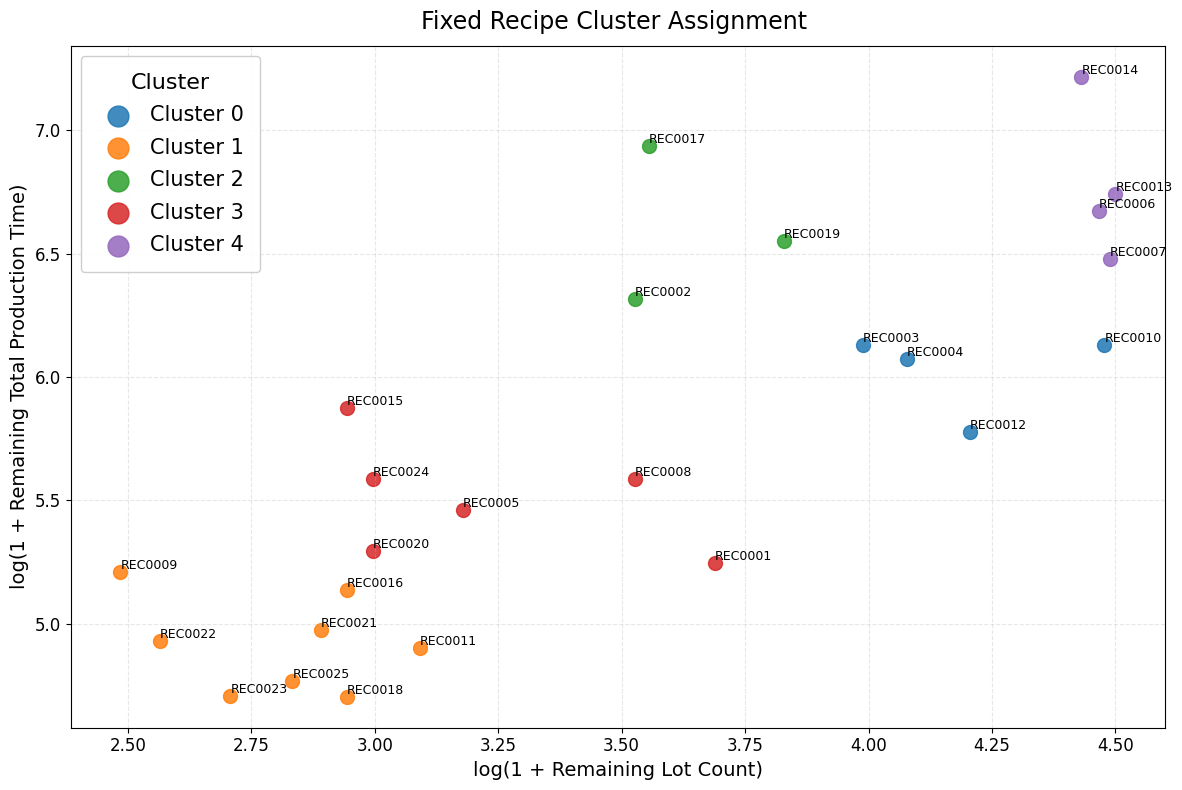

,CLUSTER,recipe_count,lot_count,urgent_lot_count,urgent_lot_ratio,total_proc,machine_count,proc_ratio,machine_ratio
0,0,4,264.0,19,0.071970,1672.349976,30,0.163829,0.200000
1,1,8,127.0,29,0.228346,1100.600021,30,0.107818,0.200000
2,2,3,112.0,8,0.071429,2276.649902,25,0.223028,0.166667
3,3,6,151.0,19,0.125828,1508.449982,25,0.147773,0.166667
4,4,4,346.0,3,0.008671,3649.850037,40,0.357552,0.266667


In [ ]:
env.print_cluster_balance_summary(
    plot=True,
    upper_agent=upper_agent
)

# Train

In [ ]:
# lower_agent.load_model('best_lower_agent.pth')
# upper_agent.load_model('best_upper_agent.pth')

In [ ]:
import time
start_time = time.perf_counter()

best_train_reward, best_schedule, history_rewards, history_tardiness, history_setup = train_hierarchical_agents_multi_lower(
    upper_agent=upper_agent,
    lower_agents=lower_agents,
    env=env,
    num_episodes=NUM_EPISODES,
    machine_available_time_limit=LIMIT_TIME,
    best_schedule_last_n_episodes=100,
    device=device

)

end_time = time.perf_counter()
print(f"執行時間: {(end_time - start_time)/60:.4f} 分")


總訓練 episodes：2000
[Hierarchical SelectMach+ Multi-PPO] Ep 10/2000 | Reward=-167.31 | Tardiness=141.57 | SetupCount=1081.00 | Limit=144.00 | SelectableMachines=150 | MachineQuota={0: 30, 1: 30, 2: 25, 3: 25, 4: 40} | ClusterLots={0: 264.0, 1: 127.0, 2: 112.0, 3: 151.0, 4: 346.0} | ClusterProc={0: 1672.3499755859375, 1: 1100.60009765625, 2: 2276.64990234375, 3: 1508.449951171875, 4: 3649.849853515625} | ClusterRecipes={0: 4, 1: 8, 2: 3, 3: 6, 4: 4} | TrackingBest=False | StartAtEpisode=1901
[Hierarchical SelectMach+ Multi-PPO] Ep 20/2000 | Reward=-223.49 | Tardiness=213.49 | SetupCount=1054.00 | Limit=144.00 | SelectableMachines=150 | MachineQuota={0: 30, 1: 30, 2: 25, 3: 25, 4: 40} | ClusterLots={0: 264.0, 1: 127.0, 2: 112.0, 3: 151.0, 4: 346.0} | ClusterProc={0: 1672.3499755859375, 1: 1100.60009765625, 2: 2276.64990234375, 3: 1508.449951171875, 4: 3649.849853515625} | ClusterRecipes={0: 4, 1: 8, 2: 3, 3: 6, 4: 4} | TrackingBest=False | StartAtEpisode=1901
[Hierarchical SelectMach+ Mult

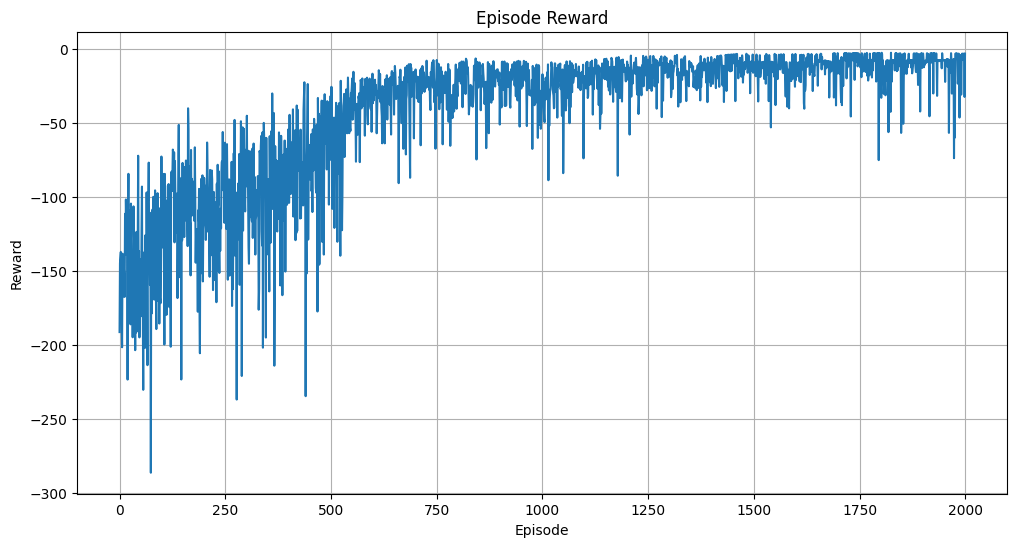

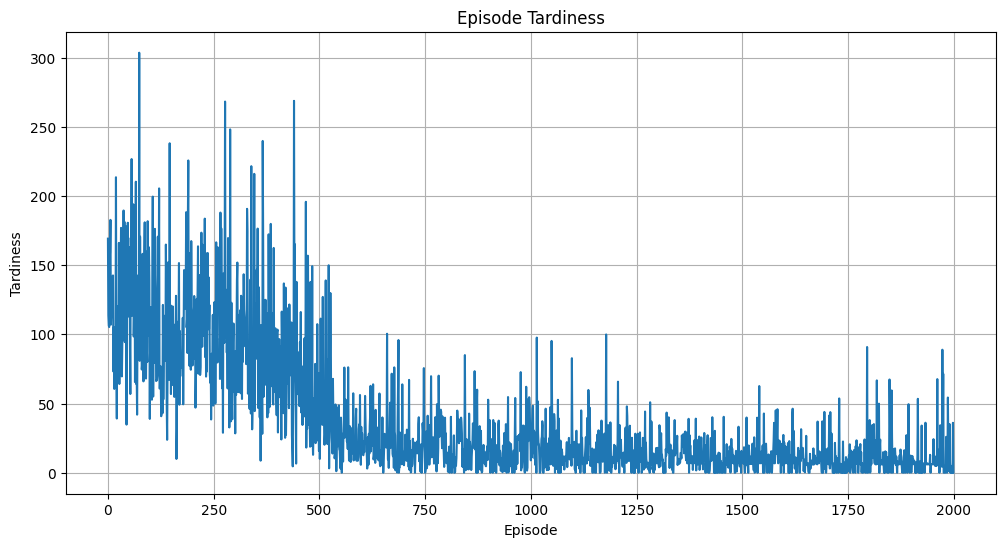

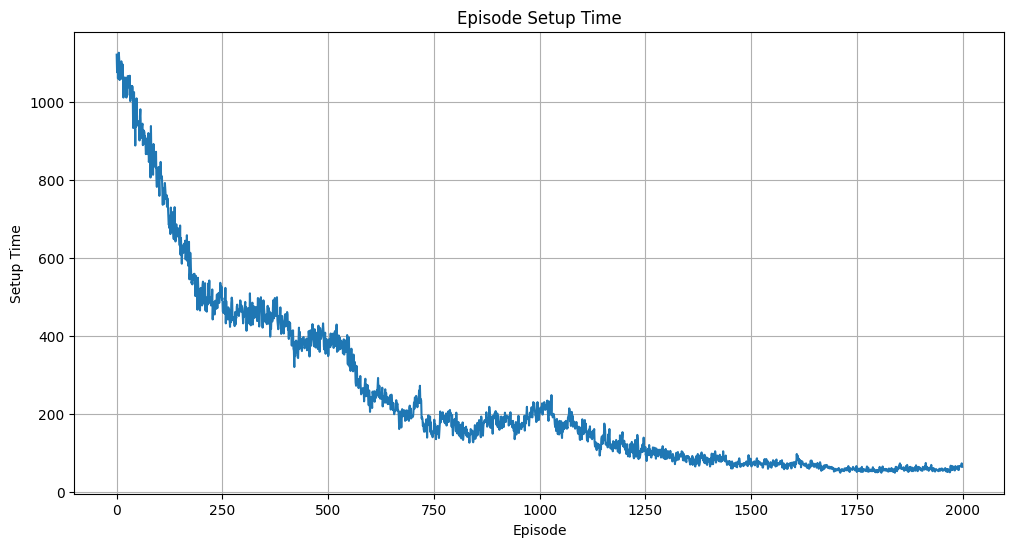

In [ ]:
plot_training_curves(
    history_rewards,
    history_tardiness,
    history_setup,
    fig_size=(12, 6)
)

# Schedule

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from plotly.colors import qualitative


# ============================================================
# 共用工具：準備甘特圖資料
# ============================================================
def _prepare_schedule_gantt_data(df):
    """
    共用資料整理。

    重要時間定義
    ----------
    Start:
        改機開始時間。如果不需改機，就是加工開始時間。

    ProcessStart:
        真正加工開始時間。
        ProcessStart = Start + SetupHour

    Finish:
        加工完成時間。

    因此 Plotly bar 使用：
        x_start = ProcessStart
        x_end   = Finish

    改機時間會自然顯示成 bar 前方的空白區段。
    """

    if df is None or len(df) == 0:
        return None, None, None

    df = df.copy()

    required_columns = [
        "GroupIdx",
        "Start",
        "Finish",
    ]

    missing_columns = [
        col
        for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        raise ValueError(
            f"df 缺少必要欄位：{missing_columns}"
        )

    # --------------------------------------------------------
    # 1. 日期欄位
    # --------------------------------------------------------
    df["Start"] = pd.to_datetime(
        df["Start"],
        errors="coerce",
    )

    df["Finish"] = pd.to_datetime(
        df["Finish"],
        errors="coerce",
    )

    if df["Start"].isna().any():
        raise ValueError("Start 欄位包含無法解析的時間。")

    if df["Finish"].isna().any():
        raise ValueError("Finish 欄位包含無法解析的時間。")

    # --------------------------------------------------------
    # 2. SetupHour
    # --------------------------------------------------------
    if "SetupHour" not in df.columns:
        df["SetupHour"] = 0.0

    df["SetupHour"] = (
        pd.to_numeric(
            df["SetupHour"],
            errors="coerce",
        )
        .fillna(0.0)
        .clip(lower=0.0)
    )

    # --------------------------------------------------------
    # 3. Changeover
    # --------------------------------------------------------
    if "Changeover" not in df.columns:
        df["Changeover"] = df["SetupHour"] > 0

    elif df["Changeover"].dtype == object:
        changeover_text = (
            df["Changeover"]
            .astype(str)
            .str.strip()
            .str.lower()
        )

        mapped_changeover = changeover_text.map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
            "yes": True,
            "no": False,
        })

        df["Changeover"] = (
            mapped_changeover
            .fillna(df["SetupHour"] > 0)
            .astype(bool)
        )

    else:
        df["Changeover"] = (
            df["Changeover"]
            .fillna(False)
            .astype(bool)
        )

    # 若 Changeover=False，強制不保留 setup gap
    df.loc[
        ~df["Changeover"],
        "SetupHour",
    ] = 0.0

    # --------------------------------------------------------
    # 4. 真正加工開始時間
    # --------------------------------------------------------
    df["ProcessStart"] = (
        df["Start"]
        + pd.to_timedelta(
            df["SetupHour"],
            unit="h",
        )
    )

    # 防止錯誤資料造成 ProcessStart > Finish
    invalid_time_mask = (
        df["ProcessStart"] > df["Finish"]
    )

    if invalid_time_mask.any():
        bad_rows = df.loc[
            invalid_time_mask,
            [
                col
                for col in [
                    "LotIdx",
                    "GroupIdx",
                    "Start",
                    "ProcessStart",
                    "Finish",
                    "SetupHour",
                ]
                if col in df.columns
            ]
        ]

        raise ValueError(
            "部分資料的 ProcessStart 晚於 Finish：\n"
            f"{bad_rows.head(20)}"
        )

    # --------------------------------------------------------
    # 5. 小時欄位
    # --------------------------------------------------------
    if "StartHour" not in df.columns:
        base_time = df["Start"].min()

        df["StartHour"] = (
            df["Start"] - base_time
        ).dt.total_seconds() / 3600.0

    if "FinishHour" not in df.columns:
        base_time = df["Start"].min()

        df["FinishHour"] = (
            df["Finish"] - base_time
        ).dt.total_seconds() / 3600.0

    df["ProcessStartHour"] = (
        pd.to_numeric(
            df["StartHour"],
            errors="coerce",
        ).fillna(0.0)
        + df["SetupHour"]
    )

    # --------------------------------------------------------
    # 6. Group 名稱
    # --------------------------------------------------------
    df["GroupIdx"] = (
        pd.to_numeric(
            df["GroupIdx"],
            errors="coerce",
        )
        .fillna(-1)
        .astype(int)
    )

    if "Group" not in df.columns:
        df["Group"] = df["GroupIdx"].apply(
            lambda g: f"G{int(g) + 1}"
        )
    else:
        df["Group"] = df["Group"].astype(str)

    # --------------------------------------------------------
    # 7. y 軸順序
    #
    # 目標：
    # 上方為 C0 與較小 GroupIdx；
    # 下方依序為 C1、C2...
    # --------------------------------------------------------
    if "Cluster" in df.columns:
        df["Cluster"] = (
            pd.to_numeric(
                df["Cluster"],
                errors="coerce",
            )
            .fillna(-1)
            .astype(int)
        )

        df["GroupDisplay"] = (
            "C"
            + df["Cluster"].astype(str)
            + " - "
            + df["Group"].astype(str)
        )

        display_order_df = (
            df[
                [
                    "Cluster",
                    "GroupIdx",
                    "GroupDisplay",
                ]
            ]
            .drop_duplicates()
            .sort_values(
                ["Cluster", "GroupIdx"],
                ascending=[True, True],
            )
        )

    else:
        df["GroupDisplay"] = df["Group"]

        display_order_df = (
            df[
                [
                    "GroupIdx",
                    "GroupDisplay",
                ]
            ]
            .drop_duplicates()
            .sort_values(
                "GroupIdx",
                ascending=True,
            )
        )

    # Plotly categoryarray 的第一個類別預設在下方，
    # 所以這裡使用反向陣列，讓 C0、較小 GroupIdx 出現在最上方。
    group_display_order = (
        display_order_df["GroupDisplay"]
        .tolist()
    )

    plotly_group_order = (
        group_display_order[::-1]
    )

    df["GroupDisplay"] = pd.Categorical(
        df["GroupDisplay"],
        categories=plotly_group_order,
        ordered=True,
    )

    # --------------------------------------------------------
    # 8. 排序
    # --------------------------------------------------------
    sort_columns = []

    if "Cluster" in df.columns:
        sort_columns.append("Cluster")

    sort_columns.extend([
        "GroupIdx",
        "ProcessStart",
        "Finish",
    ])

    df = (
        df.sort_values(sort_columns)
        .reset_index(drop=True)
    )

    return (
        df,
        "GroupDisplay",
        plotly_group_order,
    )


# ============================================================
# 共用工具：Hover 欄位
# ============================================================
def _build_schedule_hover_data(
    df,
    color_column=None,
    include_lot_label=False,
):
    hover_data = {}

    if "LotIdx" in df.columns:
        hover_data["LotIdx"] = True

    if "Cluster" in df.columns:
        hover_data["Cluster"] = True

    if "Group" in df.columns:
        hover_data["Group"] = True

    if "Recipe" in df.columns:
        hover_data["Recipe"] = True

    if "StartHour" in df.columns:
        hover_data["StartHour"] = ":.2f"

    if "SetupHour" in df.columns:
        hover_data["SetupHour"] = ":.2f"

    if "ProcessStartHour" in df.columns:
        hover_data["ProcessStartHour"] = ":.2f"

    if "FinishHour" in df.columns:
        hover_data["FinishHour"] = ":.2f"

    if "ProcHour" in df.columns:
        hover_data["ProcHour"] = ":.2f"

    if "Changeover" in df.columns:
        hover_data["Changeover"] = True

    if "Tardiness" in df.columns:
        hover_data["Tardiness"] = ":.2f"

    if "DueHour" in df.columns:
        hover_data["DueHour"] = ":.2f"

    if "Reward" in df.columns:
        hover_data["Reward"] = ":.4f"

    if "SelectableLimitHour" in df.columns:
        hover_data["SelectableLimitHour"] = ":.2f"

    # 隱藏 Plotly 自動欄位
    hover_data["Start"] = False
    hover_data["ProcessStart"] = False
    hover_data["Finish"] = False
    hover_data["GroupDisplay"] = False

    if color_column is not None:
        hover_data[color_column] = False

    if include_lot_label:
        hover_data["LotLabel"] = False

    return hover_data


# ============================================================
# 共用工具：圖表樣式
# ============================================================
def _apply_schedule_gantt_style(
    fig,
    group_order,
    legend_title,
    height,
    width,
    show_x_grid,
):
    # y 軸不再使用 autorange="reversed"
    # group_order 已經預先反向，可保證 C0 在最上面
    fig.update_yaxes(
        title="Cluster - Machine Group",
        showgrid=False,
        showline=True,
        linecolor="black",
        linewidth=1,
        ticks="outside",
        tickcolor="black",
        tickwidth=1,
        categoryorder="array",
        categoryarray=group_order,
    )

    fig.update_xaxes(
        title="Time",
        showgrid=show_x_grid,
        gridcolor="black",
        gridwidth=0.8,
        showline=True,
        linecolor="black",
        linewidth=1,
        ticks="outside",
        tickcolor="black",
        tickwidth=1,
    )

    fig.update_layout(
        height=height,
        width=width,
        legend_title_text=legend_title,
        bargap=0.15,
        paper_bgcolor="white",
        plot_bgcolor="white",
        font=dict(color="black"),
        margin=dict(
            l=120,
            r=40,
            t=80,
            b=60,
        ),
    )

    fig.update_traces(
        marker_line_color="black",
        marker_line_width=0.5,
    )

    return fig


# ============================================================
# 1. 依 Tardiness 上色
# ============================================================
def plot_schedule_gantt_by_tardiness(
    df,
    title="Wire Bond Schedule Gantt by Tardiness",
    height=900,
    width=1600,
    show_x_grid=True,
):
    """
    顏色：
        Tardiness > 0：紅色
        Tardiness = 0：綠色

    改機時間：
        不畫 bar，直接顯示成加工 bar 前方的空白。
    """

    prepared = _prepare_schedule_gantt_data(df)

    if prepared[0] is None:
        print("沒有資料可畫。")
        return None

    df, y_col, group_order = prepared

    if "Tardiness" not in df.columns:
        df["Tardiness"] = 0.0

    df["Tardiness"] = (
        pd.to_numeric(
            df["Tardiness"],
            errors="coerce",
        )
        .fillna(0.0)
    )

    df["TardinessStatus"] = np.where(
        df["Tardiness"] > 0,
        "Tardiness > 0",
        "Tardiness = 0",
    )

    color_map = {
        "Tardiness > 0": "red",
        "Tardiness = 0": "green",
    }

    hover_data = _build_schedule_hover_data(
        df,
        color_column="TardinessStatus",
    )

    fig = px.timeline(
        df,
        # 只畫加工時間
        x_start="ProcessStart",
        x_end="Finish",
        y=y_col,
        color="TardinessStatus",
        color_discrete_map=color_map,
        hover_data=hover_data,
        title=title,
        category_orders={
            y_col: group_order,
            "TardinessStatus": [
                "Tardiness > 0",
                "Tardiness = 0",
            ],
        },
    )

    fig = _apply_schedule_gantt_style(
        fig=fig,
        group_order=group_order,
        legend_title="Tardiness Status",
        height=height,
        width=width,
        show_x_grid=show_x_grid,
    )

    fig.show()
    return fig


# ============================================================
# 2. 依 Recipe 上色
# ============================================================
def plot_schedule_gantt(
    df,
    title="Wire Bond Schedule Gantt",
    height=900,
    width=1600,
    show_x_grid=True,
):
    """
    顏色：
        依 Recipe 分色。

    改機時間：
        不畫 bar，直接顯示成加工 bar 前方的空白。
    """

    prepared = _prepare_schedule_gantt_data(df)

    if prepared[0] is None:
        print("沒有資料可畫。")
        return None

    df, y_col, group_order = prepared

    if "Recipe" not in df.columns:
        df["Recipe"] = "Unknown"

    df["Recipe"] = (
        df["Recipe"]
        .fillna("Unknown")
        .astype(str)
    )

    recipes = list(
        df["Recipe"].drop_duplicates()
    )

    palette = (
        qualitative.Alphabet
        + qualitative.Dark24
        + qualitative.Light24
        + qualitative.Set3
    )

    color_map = {
        recipe: palette[i % len(palette)]
        for i, recipe in enumerate(recipes)
    }

    hover_data = _build_schedule_hover_data(
        df,
        color_column="Recipe",
    )

    # Recipe 仍然保留在 hover 中
    hover_data["Recipe"] = True

    fig = px.timeline(
        df,
        # 只畫加工時間
        x_start="ProcessStart",
        x_end="Finish",
        y=y_col,
        color="Recipe",
        color_discrete_map=color_map,
        hover_data=hover_data,
        title=title,
        category_orders={
            y_col: group_order,
        },
    )

    fig = _apply_schedule_gantt_style(
        fig=fig,
        group_order=group_order,
        legend_title="Recipe",
        height=height,
        width=width,
        show_x_grid=show_x_grid,
    )

    fig.show()
    return fig


# ============================================================
# 3. 依 Changeover 上色
# ============================================================
def plot_schedule_gantt_setup(
    df,
    title="Wire Bond Schedule Gantt by Changeover",
    height=900,
    width=1600,
    show_x_grid=True,
    show_lot_label=True,
):
    """
    顏色：
        Changeover = True：黃色
        Changeover = False：綠色

    改機時間：
        不畫黃色或其他區塊；
        直接顯示為加工 bar 前面的空白。

    注意：
        黃色 bar 代表「這個子批加工前發生改機」，
        但黃色 bar 本身只涵蓋加工時間。
    """

    prepared = _prepare_schedule_gantt_data(df)

    if prepared[0] is None:
        print("沒有資料可畫。")
        return None

    df, y_col, group_order = prepared

    df["ChangeoverStatus"] = np.where(
        df["Changeover"],
        "Changeover = True",
        "Changeover = False",
    )

    color_map = {
        "Changeover = True": "yellow",
        "Changeover = False": "green",
    }

    # --------------------------------------------------------
    # Lot 標籤
    # --------------------------------------------------------
    if show_lot_label and "LotIdx" in df.columns:
        df["LotLabel"] = df["LotIdx"].apply(
            lambda value: (
                f"Lot {int(value)}"
                if pd.notna(value)
                else ""
            )
        )
        text_column = "LotLabel"

    else:
        df["LotLabel"] = ""
        text_column = None

    hover_data = _build_schedule_hover_data(
        df,
        color_column="ChangeoverStatus",
        include_lot_label=True,
    )

    timeline_kwargs = {
        "data_frame": df,

        # 只畫加工時間
        "x_start": "ProcessStart",
        "x_end": "Finish",

        "y": y_col,
        "color": "ChangeoverStatus",
        "color_discrete_map": color_map,
        "hover_data": hover_data,
        "title": title,
        "category_orders": {
            y_col: group_order,
            "ChangeoverStatus": [
                "Changeover = True",
                "Changeover = False",
            ],
        },
    }

    if text_column is not None:
        timeline_kwargs["text"] = text_column

    fig = px.timeline(**timeline_kwargs)

    if show_lot_label:
        fig.update_traces(
            textposition="inside",
            insidetextanchor="middle",
            textfont=dict(
                color="black",
                size=10,
            ),
        )

    fig = _apply_schedule_gantt_style(
        fig=fig,
        group_order=group_order,
        legend_title="Changeover",
        height=height,
        width=width,
        show_x_grid=show_x_grid,
    )

    fig.update_layout(
        uniformtext_minsize=8,
        uniformtext_mode="hide",
    )

    fig.show()
    return fig

In [ ]:
plot_schedule_gantt(
    best_schedule,
    title="Schedule Gantt from 2026-01-01"
)

In [ ]:
plot_schedule_gantt_by_tardiness(
    best_schedule,
    title="Wire Bond Schedule Gantt: Tardiness Status",
    height=900,
    width=1600
)

In [ ]:
plot_schedule_gantt_setup(
    best_schedule,
    title="Wire Bond Schedule Gantt: Changeover Status",
    height=900,
    width=1600
)

# Data Work


不同 DUE_DATE 的出現次數：
  DUE_DATE  COUNT
2026-01-02     78
2026-01-03    166
2026-01-04    231
2026-01-05    305
2026-01-06    150
2026-01-07     63
2026-01-08      7


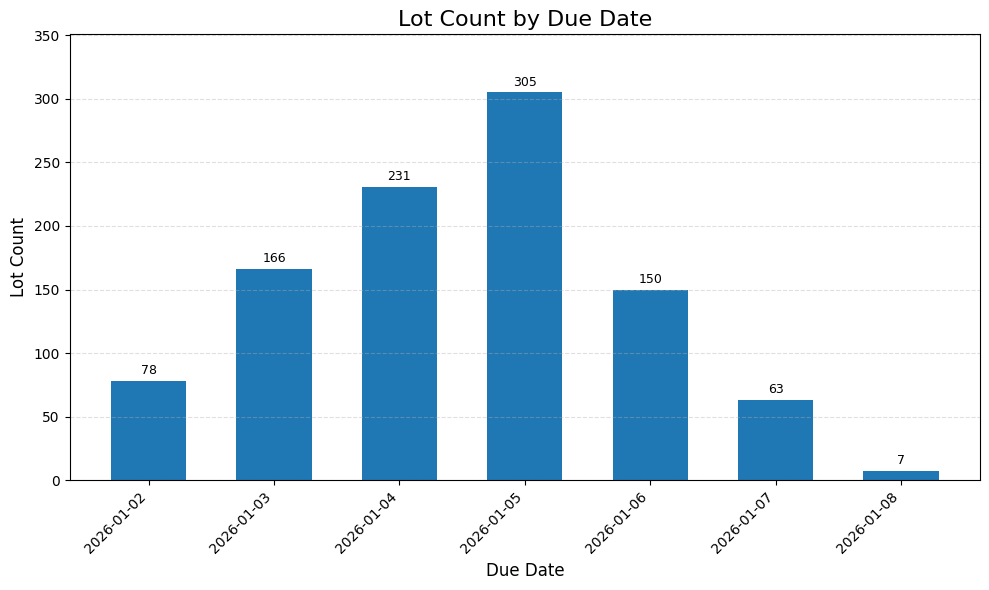

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# ============================================================
# 1. 檔案路徑
# ============================================================
input_path = "/content/drive/MyDrive/Final_Data/wip2.csv"


# ============================================================
# 2. 讀取資料
# ============================================================
df = pd.read_csv(input_path)

due_date_col = "DUE_DATE"

if due_date_col not in df.columns:
    raise ValueError(f"資料中找不到欄位：{due_date_col}")


# ============================================================
# 3. 將 DUE_DATE 轉為日期格式
# ============================================================
df[due_date_col] = pd.to_datetime(
    df[due_date_col],
    errors="coerce",
)

invalid_count = df[due_date_col].isna().sum()

if invalid_count > 0:
    print(f"無法轉換為日期的資料筆數：{invalid_count}")


# ============================================================
# 4. 統計每個 DUE_DATE 的出現次數
# ============================================================
due_date_count_df = (
    df.dropna(subset=[due_date_col])
    .groupby(due_date_col)
    .size()
    .reset_index(name="COUNT")
    .sort_values(due_date_col)
    .reset_index(drop=True)
)

print("\n不同 DUE_DATE 的出現次數：")
print(due_date_count_df.to_string(index=False))


# ============================================================
# 5. 畫長條圖
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    due_date_count_df[due_date_col],
    due_date_count_df["COUNT"],
    width=0.6,
)

ax.set_title(
    "Lot Count by Due Date",
    fontsize=16,
)

ax.set_xlabel(
    "Due Date",
    fontsize=12,
)

ax.set_ylabel(
    "Lot Count",
    fontsize=12,
)

# 日期顯示格式
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

# 在長條上標示數量
max_count = due_date_count_df["COUNT"].max()

for bar, count in zip(bars, due_date_count_df["COUNT"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_count * 0.01,
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.set_ylim(
    0,
    max_count * 1.15,
)

plt.tight_layout()
plt.show()

原始資料數：1000
有效資料數：1000
移除資料數：0

每個 Recipe 的統計結果：
RECIPENAME  LOT_COUNT  TOTAL_PRODUCTION_TIME  MIN_DUE_HOUR  MEAN_DUE_HOUR  MAX_DUE_HOUR
   REC0001         39                 189.15          72.0          83.69         120.0
   REC0002         33                 551.90          48.0          80.00          96.0
   REC0003         53                 458.40          24.0          74.72         168.0
   REC0004         58                 433.55          48.0          99.72         144.0
   REC0005         23                 234.40          72.0         113.74         120.0
   REC0006         86                 791.15          72.0          99.07         120.0
   REC0007         88                 649.60          24.0          65.73          72.0
   REC0008         33                 265.95          48.0          77.82          96.0
   REC0009         11                 181.60          48.0          48.00          48.0
   REC0010         87                 459.15          48.0          81.9

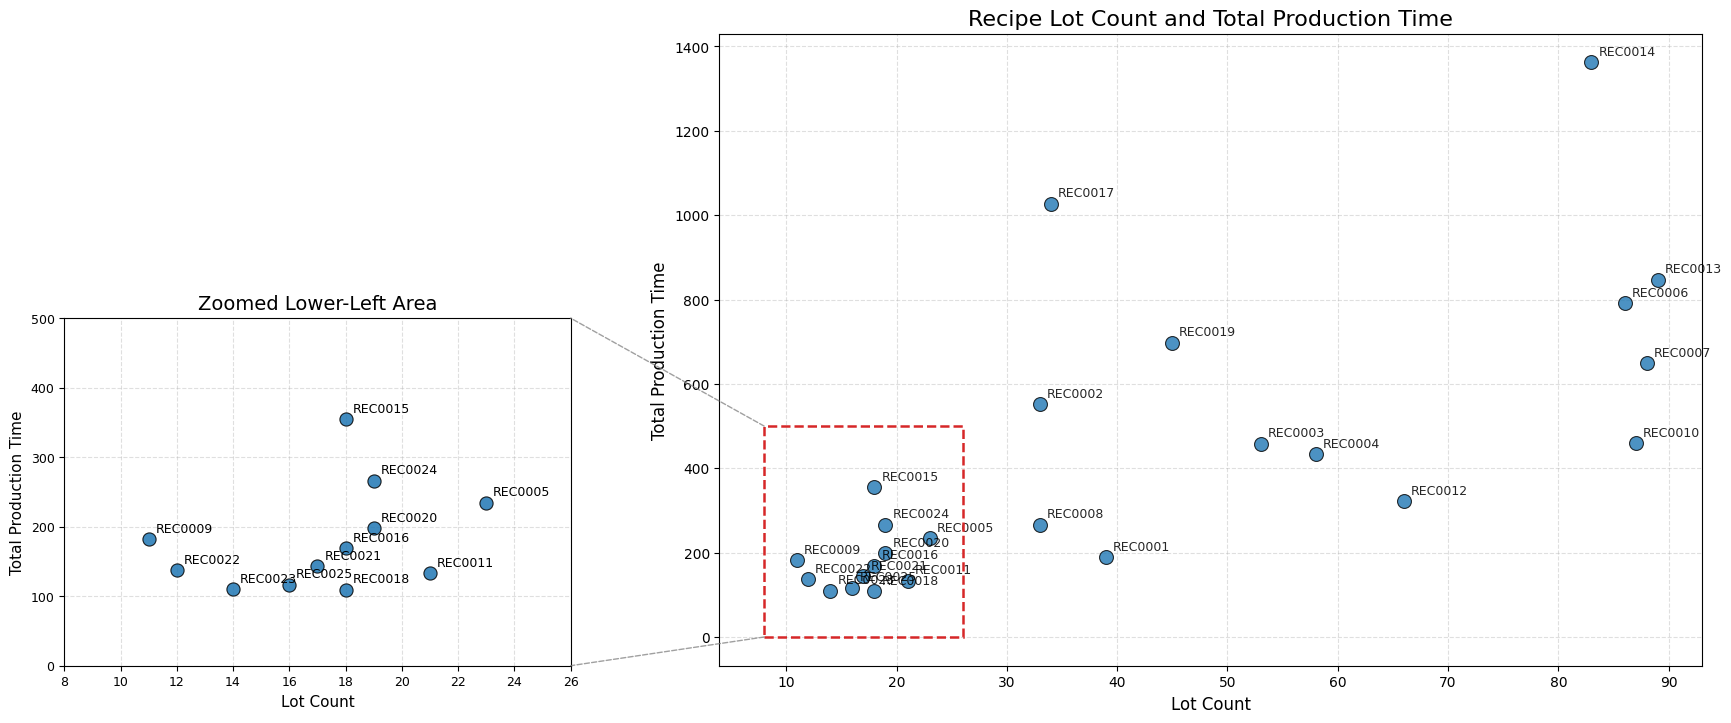

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, ConnectionPatch


# ============================================================
# 1. 檔案路徑
# ============================================================
input_path = "/content/drive/MyDrive/Final_Data/wip2.csv"


# ============================================================
# 2. 欄位設定
# ============================================================
recipe_col = "RECIPENAME"
due_date_col = "DUE_DATE"
process_time_col = "PROD_TIME"

base_date = pd.Timestamp("2026-01-01 00:00:00")


# ============================================================
# 3. 放大區域與版面設定
# ============================================================

# 手動設定紅框與左圖的共同範圍
# x 軸：Lot Count
focus_xlim = (8, 26)

# y 軸：Total Production Time
focus_ylim = (0, 500)

# 左圖高度約為右圖高度的比例
left_plot_height_ratio = 0.55

# 是否顯示主圖與左圖之間的連接線
show_connection_lines = True


# ============================================================
# 4. 讀取資料
# ============================================================
df = pd.read_csv(input_path)

required_columns = [
    recipe_col,
    due_date_col,
    process_time_col,
]

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"輸入資料缺少必要欄位：{missing_columns}\n"
        f"目前欄位為：{df.columns.tolist()}"
    )


# ============================================================
# 5. 資料清理
# ============================================================

# Recipe 轉為字串並移除前後空白
df[recipe_col] = (
    df[recipe_col]
    .astype("string")
    .str.strip()
)

# 空字串與字串 nan 視為缺失值
invalid_recipe_mask = (
    df[recipe_col].isna()
    | df[recipe_col].eq("")
    | df[recipe_col].str.lower().eq("nan")
)

df.loc[
    invalid_recipe_mask,
    recipe_col,
] = pd.NA

# 加工時間轉為數值
df[process_time_col] = pd.to_numeric(
    df[process_time_col],
    errors="coerce",
)

# DUE_DATE 轉為日期時間
df[due_date_col] = pd.to_datetime(
    df[due_date_col],
    errors="coerce",
)

# 移除必要欄位缺失的資料
before_count = len(df)

df = df.dropna(
    subset=[
        recipe_col,
        due_date_col,
        process_time_col,
    ]
).copy()

after_count = len(df)

print(f"原始資料數：{before_count}")
print(f"有效資料數：{after_count}")
print(f"移除資料數：{before_count - after_count}")


# ============================================================
# 6. 將 DUE_DATE 轉成距離 2026/1/1 的小時數
# ============================================================
df["DUE_HOUR"] = (
    df[due_date_col] - base_date
).dt.total_seconds() / 3600.0


# ============================================================
# 7. 統計每個 Recipe
# ============================================================
recipe_summary = (
    df.groupby(recipe_col)
    .agg(
        LOT_COUNT=(recipe_col, "size"),
        TOTAL_PRODUCTION_TIME=(process_time_col, "sum"),
        MIN_DUE_HOUR=("DUE_HOUR", "min"),
        MEAN_DUE_HOUR=("DUE_HOUR", "mean"),
        MAX_DUE_HOUR=("DUE_HOUR", "max"),
    )
    .reset_index()
    .sort_values(recipe_col)
    .reset_index(drop=True)
)

round_columns = [
    "TOTAL_PRODUCTION_TIME",
    "MIN_DUE_HOUR",
    "MEAN_DUE_HOUR",
    "MAX_DUE_HOUR",
]

recipe_summary[round_columns] = (
    recipe_summary[round_columns].round(2)
)


# ============================================================
# 8. 顯示統計結果
# ============================================================
print("\n每個 Recipe 的統計結果：")
print(recipe_summary.to_string(index=False))


# ============================================================
# 9. 取得紅框範圍內的 Recipe
# ============================================================
focus_mask = (
    recipe_summary["LOT_COUNT"].between(
        focus_xlim[0],
        focus_xlim[1],
        inclusive="both",
    )
    & recipe_summary["TOTAL_PRODUCTION_TIME"].between(
        focus_ylim[0],
        focus_ylim[1],
        inclusive="both",
    )
)

focus_df = (
    recipe_summary.loc[focus_mask]
    .copy()
    .reset_index(drop=True)
)

if focus_df.empty:
    print(
        "\n警告：目前紅框範圍內沒有 Recipe，"
        "請調整 focus_xlim 或 focus_ylim。"
    )


# ============================================================
# 10. 設定左圖高度
# ============================================================
left_plot_height_ratio = min(
    max(left_plot_height_ratio, 0.20),
    1.00,
)

top_space_ratio = (
    1.0 - left_plot_height_ratio
)


# ============================================================
# 11. 建立圖形版面
# ============================================================
fig = plt.figure(
    figsize=(18, 8),
)

grid = fig.add_gridspec(
    nrows=2,
    ncols=2,

    # 左圖較窄、右圖較寬
    width_ratios=[
        0.85,
        1.65,
    ],

    # 第一列為左圖上方留白
    # 第二列為左圖本體
    height_ratios=[
        top_space_ratio,
        left_plot_height_ratio,
    ],

    wspace=0.20,
    hspace=0.00,
)

# 左圖放在左下方
ax_zoom = fig.add_subplot(
    grid[1, 0]
)

# 右圖占滿完整高度
ax_main = fig.add_subplot(
    grid[:, 1]
)


# ============================================================
# 12. 左側放大圖
# ============================================================
ax_zoom.scatter(
    focus_df["LOT_COUNT"],
    focus_df["TOTAL_PRODUCTION_TIME"],
    s=90,
    color="tab:blue",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.8,
    zorder=3,
)

# 左圖標註 Recipe
for _, row in focus_df.iterrows():
    ax_zoom.annotate(
        text=row[recipe_col],
        xy=(
            row["LOT_COUNT"],
            row["TOTAL_PRODUCTION_TIME"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        zorder=4,
    )

# 左圖範圍與紅框完全相同
ax_zoom.set_xlim(focus_xlim)
ax_zoom.set_ylim(focus_ylim)

ax_zoom.set_title(
    "Zoomed Lower-Left Area",
    fontsize=14,
)

ax_zoom.set_xlabel(
    "Lot Count",
    fontsize=11,
)

ax_zoom.set_ylabel(
    "Total Production Time",
    fontsize=11,
)

ax_zoom.tick_params(
    axis="both",
    labelsize=9,
)

ax_zoom.grid(
    True,
    linestyle="--",
    alpha=0.4,
)


# ============================================================
# 13. 右側完整主圖
# ============================================================
ax_main.scatter(
    recipe_summary["LOT_COUNT"],
    recipe_summary["TOTAL_PRODUCTION_TIME"],
    s=100,
    color="tab:blue",
    alpha=0.8,
    edgecolors="black",
    linewidths=0.8,
    zorder=3,
)

# 主圖標註 Recipe
for _, row in recipe_summary.iterrows():
    ax_main.annotate(
        text=row[recipe_col],
        xy=(
            row["LOT_COUNT"],
            row["TOTAL_PRODUCTION_TIME"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        alpha=0.85,
        zorder=4,
    )

ax_main.set_title(
    "Recipe Lot Count and Total Production Time",
    fontsize=16,
)

ax_main.set_xlabel(
    "Lot Count",
    fontsize=12,
)

ax_main.set_ylabel(
    "Total Production Time",
    fontsize=12,
)

ax_main.grid(
    True,
    linestyle="--",
    alpha=0.4,
)


# ============================================================
# 14. 在主圖畫出紅色虛線框
# ============================================================
zoom_rectangle = Rectangle(
    xy=(
        focus_xlim[0],
        focus_ylim[0],
    ),
    width=(
        focus_xlim[1] - focus_xlim[0]
    ),
    height=(
        focus_ylim[1] - focus_ylim[0]
    ),
    fill=False,
    edgecolor="tab:red",
    linewidth=1.8,
    linestyle="--",
    zorder=5,
)

ax_main.add_patch(zoom_rectangle)


# ============================================================
# 15. 加入主圖與左圖之間的連接線
# ============================================================
if show_connection_lines:
    # 紅框左上角連到左圖右上角
    connection_top = ConnectionPatch(
        xyA=(
            focus_xlim[0],
            focus_ylim[1],
        ),
        coordsA=ax_main.transData,

        xyB=(
            focus_xlim[1],
            focus_ylim[1],
        ),
        coordsB=ax_zoom.transData,

        color="gray",
        linewidth=1.0,
        linestyle="--",
        alpha=0.75,
        zorder=2,
    )

    # 紅框左下角連到左圖右下角
    connection_bottom = ConnectionPatch(
        xyA=(
            focus_xlim[0],
            focus_ylim[0],
        ),
        coordsA=ax_main.transData,

        xyB=(
            focus_xlim[1],
            focus_ylim[0],
        ),
        coordsB=ax_zoom.transData,

        color="gray",
        linewidth=1.0,
        linestyle="--",
        alpha=0.75,
        zorder=2,
    )

    fig.add_artist(connection_top)
    fig.add_artist(connection_bottom)


# ============================================================
# 16. 顯示紅框範圍資訊
# ============================================================
print("\n紅框內、同時也是左圖顯示的 Recipe：")

if focus_df.empty:
    print("目前紅框範圍內沒有 Recipe。")
else:
    print(
        focus_df[
            [
                recipe_col,
                "LOT_COUNT",
                "TOTAL_PRODUCTION_TIME",
            ]
        ].to_string(index=False)
    )

print(
    "\n紅框與左圖共同範圍："
    f"\nLOT_COUNT："
    f"{focus_xlim[0]:.2f} ～ {focus_xlim[1]:.2f}"
    f"\nTOTAL_PRODUCTION_TIME："
    f"{focus_ylim[0]:.2f} ～ {focus_ylim[1]:.2f}"
)


# ============================================================
# 17. 圖形邊界設定
# ============================================================
plt.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.90,
    bottom=0.11,
)

plt.show()

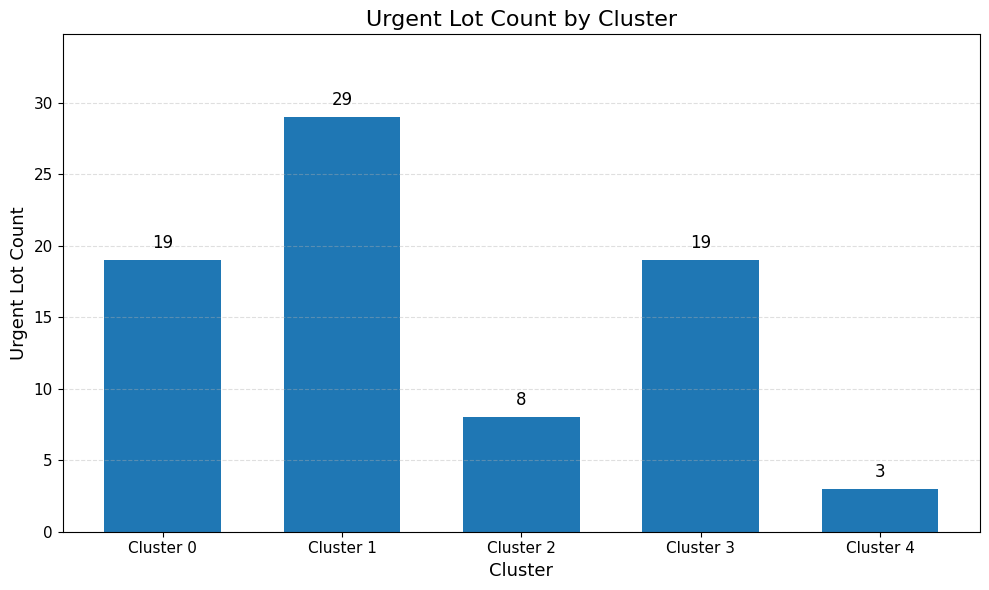

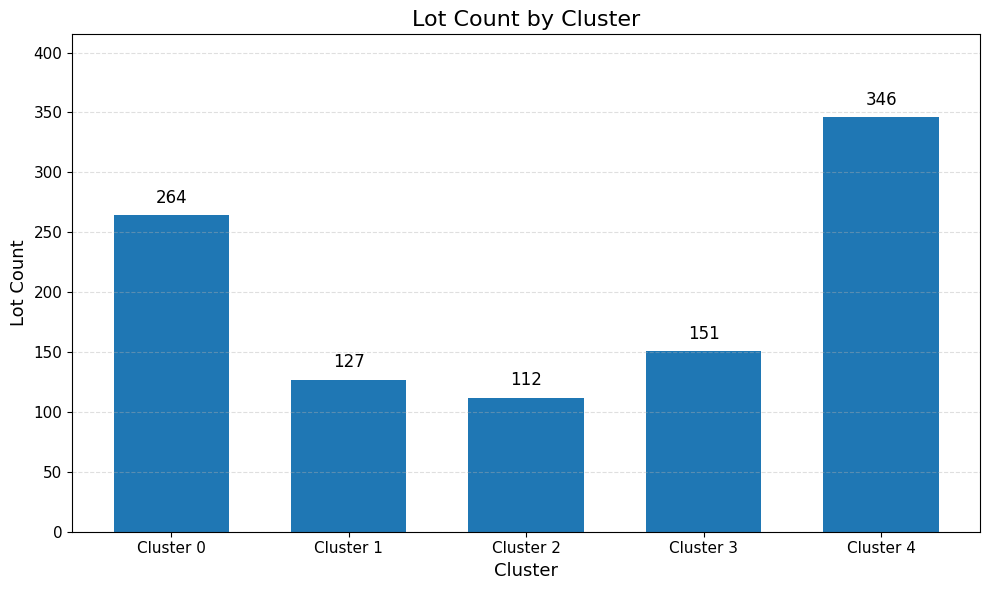

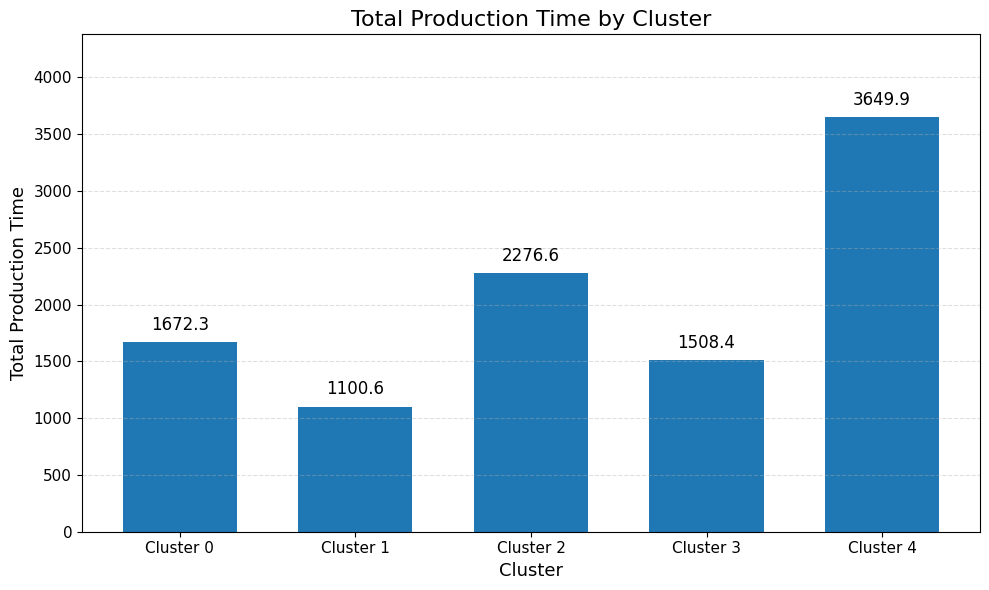

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. 建立 Cluster summary 資料
# ============================================================
summary_df = pd.DataFrame({
    "CLUSTER": [0, 1, 2, 3, 4],
    "recipe_count": [4, 8, 3, 6, 4],
    "lot_count": [264.0, 127.0, 112.0, 151.0, 346.0],
    "urgent_lot_count": [19, 29, 8, 19, 3],
    "urgent_lot_ratio": [
        0.071970,
        0.228346,
        0.071429,
        0.125828,
        0.008671,
    ],
    "total_proc": [
        1672.349976,
        1100.600021,
        2276.649902,
        1508.449982,
        3649.850037,
    ],
    "machine_count": [25, 30, 30, 25, 40],
    "proc_ratio": [
        0.163829,
        0.107818,
        0.223028,
        0.147773,
        0.357552,
    ],
    "machine_ratio": [
        0.166667,
        0.200000,
        0.200000,
        0.166667,
        0.266667,
    ],
})


# ============================================================
# 2. 基本設定
# ============================================================
x = summary_df["CLUSTER"]
cluster_labels = [
    f"Cluster {cluster_id}"
    for cluster_id in summary_df["CLUSTER"]
]


# ============================================================
# 3. 第一張圖：每個 Cluster 的急單數
# ============================================================
fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    x,
    summary_df["urgent_lot_count"],
    width=0.65,
)

ax.set_title(
    "Urgent Lot Count by Cluster",
    fontsize=16,
)

ax.set_xlabel(
    "Cluster",
    fontsize=13,
)

ax.set_ylabel(
    "Urgent Lot Count",
    fontsize=13,
)

ax.set_xticks(x)
ax.set_xticklabels(
    cluster_labels,
    fontsize=11,
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

max_urgent_count = max(
    1,
    int(
        summary_df[
            "urgent_lot_count"
        ].max()
    ),
)

ax.set_ylim(
    0,
    max_urgent_count * 1.20,
)

# 顯示每個 Cluster 的急單數
for bar, count in zip(
    bars,
    summary_df["urgent_lot_count"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_urgent_count * 0.02,
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontsize=12,
    )

fig.tight_layout()
plt.show()


# ============================================================
# 4. 第二張圖：每個 Cluster 的子批數
# ============================================================
fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    x,
    summary_df["lot_count"],
    width=0.65,
)

ax.set_title(
    "Lot Count by Cluster",
    fontsize=16,
)

ax.set_xlabel(
    "Cluster",
    fontsize=13,
)

ax.set_ylabel(
    "Lot Count",
    fontsize=13,
)

ax.set_xticks(x)
ax.set_xticklabels(
    cluster_labels,
    fontsize=11,
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

max_lot_count = max(
    1,
    int(
        summary_df[
            "lot_count"
        ].max()
    ),
)

ax.set_ylim(
    0,
    max_lot_count * 1.20,
)

# 顯示每個 Cluster 的子批數
for bar, count in zip(
    bars,
    summary_df["lot_count"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_lot_count * 0.02,
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontsize=12,
    )

fig.tight_layout()
plt.show()

# ============================================================
# 5. 第三張圖：每個 Cluster 的總工時
# ============================================================
fig, ax = plt.subplots(
    figsize=(10, 6)
)

bars = ax.bar(
    x,
    summary_df["total_proc"],
    width=0.65,
)

ax.set_title(
    "Total Production Time by Cluster",
    fontsize=16,
)

ax.set_xlabel(
    "Cluster",
    fontsize=13,
)

ax.set_ylabel(
    "Total Production Time",
    fontsize=13,
)

ax.set_xticks(x)
ax.set_xticklabels(
    cluster_labels,
    fontsize=11,
)

ax.tick_params(
    axis="y",
    labelsize=11,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

max_total_proc = max(
    1.0,
    float(summary_df["total_proc"].max()),
)

ax.set_ylim(
    0,
    max_total_proc * 1.20,
)

# 顯示每個 Cluster 的總工時
for bar, total_proc in zip(
    bars,
    summary_df["total_proc"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max_total_proc * 0.02,
        f"{total_proc:.1f}",
        ha="center",
        va="bottom",
        fontsize=12,
    )

fig.tight_layout()
plt.show()

In [ ]:
import pandas as pd


# ============================================================
# 1. 檔案路徑
# ============================================================
input_path = "/content/drive/MyDrive/Final_Data/mach.csv"


# ============================================================
# 2. 讀取資料
# ============================================================
mach_df = pd.read_csv(input_path)

if "m_count" not in mach_df.columns:
    raise ValueError("mach.csv 中找不到 m_count 欄位")


# ============================================================
# 3. 將 m_count 轉成數值
# ============================================================
mach_df["m_count"] = pd.to_numeric(
    mach_df["m_count"],
    errors="coerce",
)


# ============================================================
# 4. 統計 m_count = 1 與 m_count = 2 的出現次數
# ============================================================
count_1 = int((mach_df["m_count"] == 1).sum())
count_2 = int((mach_df["m_count"] == 2).sum())


# ============================================================
# 5. 顯示結果
# ============================================================
print(f"m_count = 1 的出現次數：{count_1}")
print(f"m_count = 2 的出現次數：{count_2}")

m_count = 1 的出現次數：38
m_count = 2 的出現次數：112


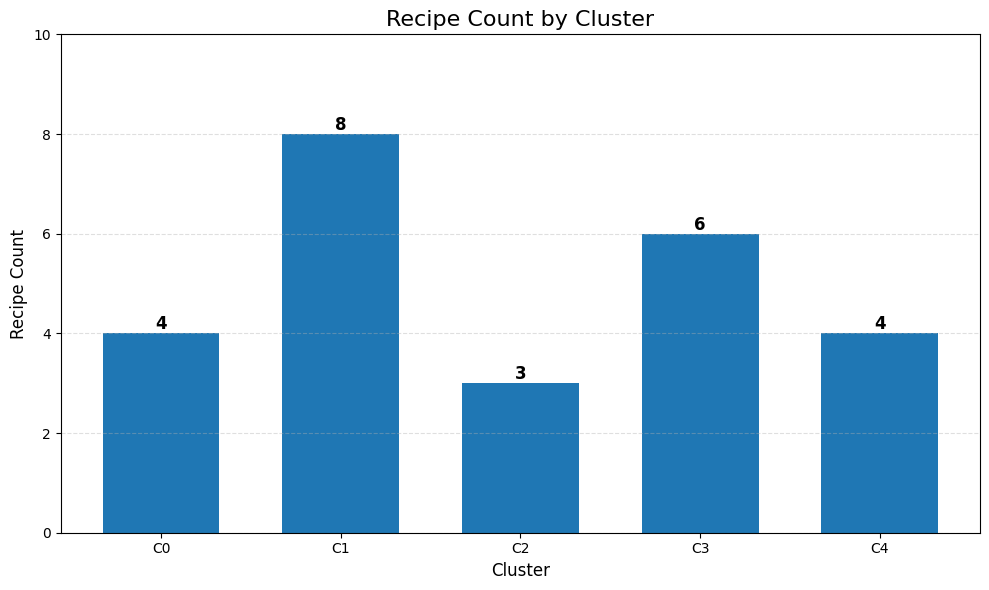

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. 建立資料
# ============================================================
summary_df = pd.DataFrame({
    "CLUSTER": [0, 1, 2, 3, 4],
    "recipe_count": [4, 8, 3, 6, 4],
})


# ============================================================
# 2. 畫每個 Cluster 的 Recipe 數量
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    summary_df["CLUSTER"],
    summary_df["recipe_count"],
    width=0.65,
)

ax.set_title(
    "Recipe Count by Cluster",
    fontsize=16,
)

ax.set_xlabel(
    "Cluster",
    fontsize=12,
)

ax.set_ylabel(
    "Recipe Count",
    fontsize=12,
)

ax.set_xticks(summary_df["CLUSTER"])
ax.set_xticklabels(
    [f"C{cluster}" for cluster in summary_df["CLUSTER"]]
)

ax.set_ylim(
    0,
    summary_df["recipe_count"].max() * 1.25,
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4,
)

# 在長條上方標示 Recipe 數量
for bar, count in zip(
    bars,
    summary_df["recipe_count"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()